# **1. Connecting to the database**

In [ ]:
# Installing a library to work with Google BigQuery
!pip install --upgrade google-cloud-bigquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-bigquery
    Found existing installation: google-cloud-bigquery 3.41.0
    Uninstalling google-cloud-bigquery-3.41.0:
      Successfully uninstalled google-cloud-bigquery-3.41.0


In [ ]:

# Libraries
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# SQL query
query = """
SELECT
  s.date,
  s.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  acs.account_id,
  acc.is_verified,
  acc.is_unsubscribed,
  p.category,
  p.name,
  p.price,
  p.short_description
FROM `DA.session` AS s
LEFT JOIN `DA.session_params` AS sp
  ON sp.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account_session` AS acs
  ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account` AS acc
  ON acc.id = acs.account_id
LEFT JOIN `DA.order` AS o
  ON o.ga_session_id = s.ga_session_id
LEFT JOIN `DA.product` AS p
  ON p.item_id = o.item_id
  """
# Executing the query
query_job = client.query(query)  # Executing the SQL query
results = query_job.result()  # Waiting for the query to complete


# Converting results to a DataFrame
df = results.to_dataframe(create_bqstorage_client=False)


# Displaying the results
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


# **2. Exploratory data analysis**

## Dataset overview
1. **date** - order date
2. **ga_session_id** - unique identifier for each session
3. **continent** - continent from which the order was placed
4. **country** - country from which the order was placed
5. **device** - device for the order
6. **browser** - browser for the order
7. **mobile_model_name** - device model name for the order
8. **operating_system** - operating system for the order
9. **language** - browser language for the order
10. **traffic_source** - marketing traffic source
11. **traffic_channel** - marketing traffic channel
12. **account_id** - unique identifier of a registered user
13. **is_verified** - user email verification status
14. **is_unsubscribed** - user newsletter subscription status
15. **category** - product category
16. **name** - product name
17. **price** - product price
18. **short_description** - short product description

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
# 0. Data preprocessing
# Convert the 'date' column to standard datetime format for accurate calculations
df['date'] = pd.to_datetime(df['date'])

# 1. Total number of columns
total_cols = df.shape[1]
print(f"1. Total number of columns: {total_cols}\n")

# 2. Number of numeric columns (and which ones)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"2. Number of numeric columns: {len(numeric_cols)}")
print(f"   Column names: {', '.join(numeric_cols)}\n")

# 3. Number of categorical columns (and which ones)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"3. Number of categorical columns: {len(categorical_cols)}")
print(f"   Column names: {', '.join(categorical_cols)}\n")

# 4. Number of datetime columns
datetime_cols = df.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()
print(f"4. Number of datetime columns: {len(datetime_cols)}")
print(f"   Column names: {', '.join(datetime_cols)}\n")

# 5. Number of unique sessions
unique_sessions = df['ga_session_id'].nunique()
print(f"5. Number of unique sessions (nunique): {unique_sessions}\n")

# 6. Time period covered (from... to...)
start_date = df['date'].min().strftime('%Y-%m-%d')
end_date = df['date'].max().strftime('%Y-%m-%d')
print(f"6. Time period: from {start_date} to {end_date}\n")

# 7. Check for duplicates
total_duplicates = df.duplicated().sum()
print(f"7. Number of exact duplicates: {total_duplicates}\n")

# 8. Are there missing values
has_missing = df.isnull().values.any()
print(f"8. Are there missing values in the table: {'Yes' if has_missing else 'No'}\n")

# 9. Which columns have the most missing values, what is the reason?
print("9. Missing values ratio by column (sorted in descending order):")
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percent.round(2)
})

# Filter only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(missing_summary)

1. Total number of columns: 18

2. Number of numeric columns: 5
   Column names: ga_session_id, account_id, is_verified, is_unsubscribed, price

3. Number of categorical columns: 12
   Column names: continent, country, device, browser, mobile_model_name, operating_system, language, traffic_source, traffic_channel, category, name, short_description

4. Number of datetime columns: 1
   Column names: date

5. Number of unique sessions (nunique): 349545

6. Time period: from 2020-11-01 to 2021-01-31

7. Number of exact duplicates: 0

8. Are there missing values in the table: Yes

9. Missing values ratio by column (sorted in descending order):
                   Missing Count  Missing Percentage (%)
account_id                321600                   92.01
is_verified               321600                   92.01
is_unsubscribed           321600                   92.01
category                  316007                   90.41
price                     316007                   90.41
name       

**Dataset Summary**

General Characteristics
The analyzed web analytics dataset contains 349,545 records (events) and 18 attributes. The records reflect detailed user activity on the website within unique sessions.

**Data Structure**

The dataset consists of columns with various data types, which can be grouped into three main categories:

* *Numeric Metrics (5):* Identifiers (ga_session_id, account_id), boolean
activity statuses (is_verified, is_unsubscribed), and financial metrics (price).

* *Categorical/Text Attributes (12)* : Describe visitor geography (country, continent), technical device parameters (device, browser, mobile_model_name, operating_system, language), traffic acquisition channels (traffic_source, traffic_channel), and content characteristics of the products.

* Temporal Dimensions (1): The calendar date of the event (date).

**Data Quality and Completeness (Missing Values)**

The dataset exhibits significant data sparsity in specific segments, which is a logical consequence of the web resource's business processes:

* Authorization Data (~92% missing): The vast majority of sessions are conducted by unauthorized guests. Client identifiers are recorded for only ~8% of events, specifically when a user logs into their personal account.

* E-commerce Data (~90.5% missing): Product information is populated exclusively during target e-commerce events (e.g., viewing a specific product or adding it to the cart). Most records reflect basic site navigation, where these parameters are absent.

* Technical Limitations: About a third of the records lack information about the browser language (language), which is usually related to user privacy settings (e.g., incognito mode, ad-blockers).

## Descriptive statistics

In [ ]:
# Summary statistics of numerical data
df.describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,2020-12-16 12:42:00.602497536,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
min,2020-11-01 00:00:00,1205.0,636133.0,0.0,0.0,3.000000
25%,2020-11-26 00:00:00,2493646855.0,647576.0,0.0,0.0,170.000000
50%,2020-12-15 00:00:00,4988476074.0,658952.0,1.0,0.0,445.000000
75%,2021-01-08 00:00:00,7491286508.0,670414.0,1.0,0.0,1195.000000
max,2021-01-31 00:00:00,9999997129.0,681962.0,1.0,1.0,9585.000000
std,NaN,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775


In [ ]:
# Number of records per category
df["category"].value_counts()

,count
category,
Bookcases & shelving units,7630
Chairs,5952
Sofas & armchairs,4301
Tables & desks,2941
Beds,2926
Cabinets & cupboards,2318
Outdoor furniture,2229
Children's furniture,1702
Chests of drawers & drawer units,1452


In [ ]:
# Top 5 countries by number of records
df["country"].value_counts().nlargest(5)

,count
country,
United States,153470
India,32763
Canada,25994
United Kingdom,11003
France,6958


In [ ]:
df["continent"].value_counts().nlargest(5)

,count
continent,
Americas,193179
Asia,83113
Europe,65135
Oceania,3703
Africa,3620


# **Analyzing and visualization**

In [ ]:
# Geographical analysis
# Working only with rows where a price is present (i.e., a real order)
orders = df.dropna(subset=['price']).copy()

# 'df' contains all sessions (349,545), but 'price' exists only where an order was placed (~33,538 rows)
# We use the 'orders' dataframe specifically for sales analysis

# --- Top 3 continents by sales amount ---
top_continents_sales = (
    orders.groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
)
top_continents_sales.columns = ['Continent', 'Total Sales']

# --- Top 3 continents by number of orders ---
top_continents_orders = (
    orders.groupby('continent')['price']
    .count()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
)
top_continents_orders.columns = ['Continent', 'Number of Orders']

print("Top 3 continents by sales amount:")
print(top_continents_sales.to_string(index=False))

print("\nTop 3 continents by number of orders:")
print(top_continents_orders.to_string(index=False))

Top 3 continents by sales amount:
Continent  Total Sales
 Americas   17665280.0
     Asia    7601298.3
   Europe    5934624.2

Top 3 continents by number of orders:
Continent  Number of Orders
 Americas             18553
     Asia              7950
   Europe              6261


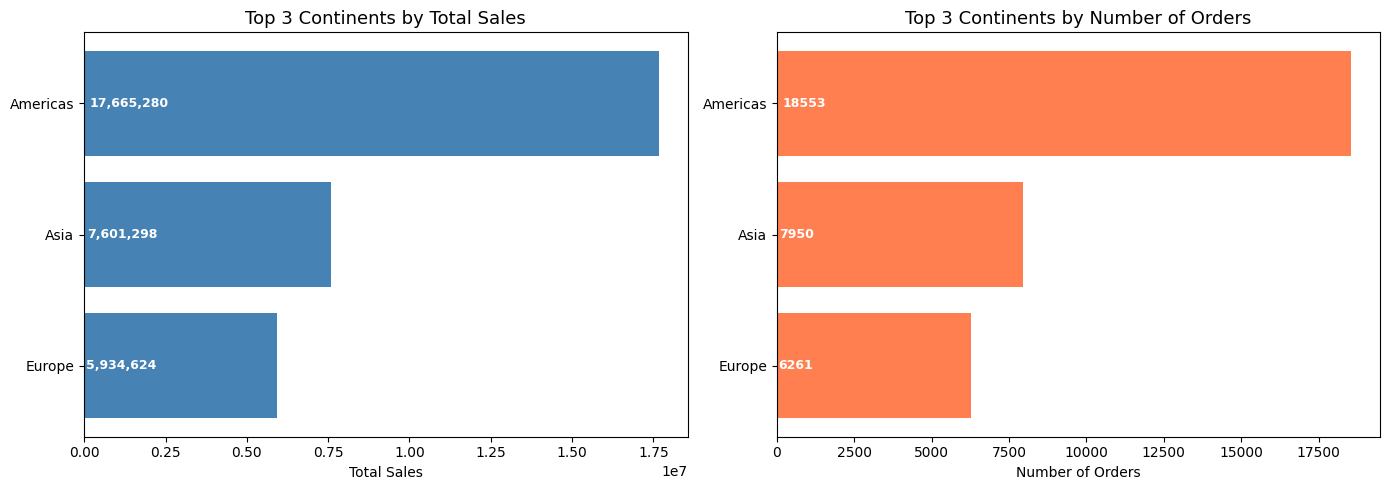

In [ ]:
# --- Visualization: double bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — total sales
axes[0].barh(top_continents_sales['Continent'], top_continents_sales['Total Sales'], color='steelblue')
axes[0].set_title('Top 3 Continents by Total Sales', fontsize=13)
axes[0].set_xlabel('Total Sales')
axes[0].invert_yaxis()
for i, v in enumerate(top_continents_sales['Total Sales']):
    axes[0].text(v * 0.01, i, f'{v:,.0f}', va='center', fontsize=9, color='white', fontweight='bold')

# Right — number of orders
axes[1].barh(top_continents_orders['Continent'], top_continents_orders['Number of Orders'], color='coral')
axes[1].set_title('Top 3 Continents by Number of Orders', fontsize=13)
axes[1].set_xlabel('Number of Orders')
axes[1].invert_yaxis()
for i, v in enumerate(top_continents_orders['Number of Orders']):
    axes[1].text(v * 0.01, i, str(v), va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('geo_top3_continents.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ──  Top 5 Countries  ───────────────────────────────────────────────────────
# --- Top 5 countries by total sales ---
top5_sales = (
    orders.groupby('country')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top5_sales.columns = ['Country', 'Total Sales']

# --- Top 5 countries by number of orders ---
top5_orders = (
    orders.groupby('country')['price']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top5_orders.columns = ['Country', 'Number of Orders']

print("Top 5 countries by total sales:")
print(top5_sales.to_string(index=False))

print("\nTop 5 countries by number of orders:")
print(top5_orders.to_string(index=False))

Top 5 countries by total sales:
       Country  Total Sales
 United States   13943553.9
         India    2809762.0
        Canada    2437921.0
United Kingdom     938317.9
        France     710692.8

Top 5 countries by number of orders:
       Country  Number of Orders
 United States             14673
         India              3029
        Canada              2560
United Kingdom              1029
        France               678


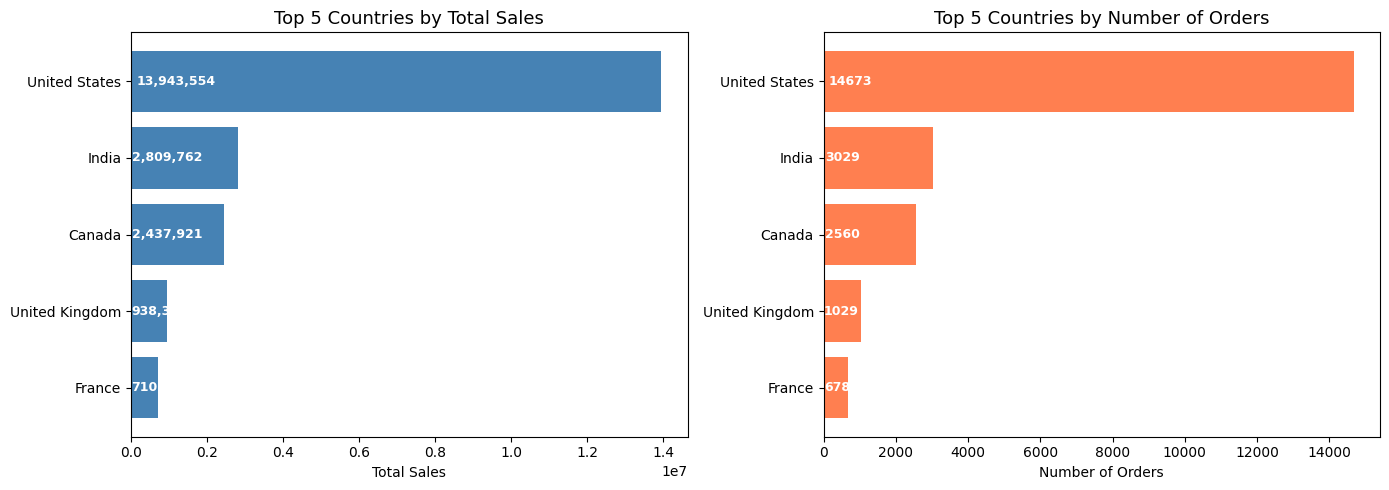

In [ ]:
# --- Visualization: double bar chart for countries ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top5_sales['Country'], top5_sales['Total Sales'], color='steelblue')
axes[0].set_title('Top 5 Countries by Total Sales', fontsize=13)
axes[0].set_xlabel('Total Sales')
axes[0].invert_yaxis()   # largest on top
for i, v in enumerate(top5_sales['Total Sales']):
    axes[0].text(v * 0.01, i, f'{v:,.0f}', va='center', fontsize=9, color='white', fontweight='bold')

axes[1].barh(top5_orders['Country'], top5_orders['Number of Orders'], color='coral')
axes[1].set_title('Top 5 Countries by Number of Orders', fontsize=13)
axes[1].set_xlabel('Number of Orders')
axes[1].invert_yaxis()
for i, v in enumerate(top5_orders['Number of Orders']):
    axes[1].text(v * 0.01, i, str(v), va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('geo_top5_countries.png', dpi=150, bbox_inches='tight')
plt.show()


By analyzing total sales and the number of orders, we can identify the top 3 continents and the top 5 countries with the highest values:

**Top 3 continents:**

1. North and South America
2. Asia
3. Europe

**Top 5 countries:**

1. United States
2. India
3. Canada
4. United Kingdom
5. France

In [ ]:
# ──  Category Analysis ──────────────────────────────────────────────────────
# --- Overall top 10 categories ---
top10_cat = (
    orders.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_cat.columns = ['Category', 'Total Sales']

# Share of total (%)
total_sales = orders['price'].sum()
top10_cat['Share (%)'] = (top10_cat['Total Sales'] / total_sales * 100).round(1)

print("Top 10 categories by total sales:")
print(top10_cat.to_string(index=False))

Top 10 categories by total sales:
                        Category  Total Sales  Share (%)
               Sofas & armchairs    8388254.5       26.2
                          Chairs    6147748.8       19.2
                            Beds    4919725.0       15.4
      Bookcases & shelving units    3640818.1       11.4
            Cabinets & cupboards    2336499.5        7.3
               Outdoor furniture    2142222.2        6.7
                  Tables & desks    1790307.5        5.6
Chests of drawers & drawer units     906562.5        2.8
                   Bar furniture     735503.0        2.3
            Children's furniture     467697.0        1.5


In [ ]:
# --- Comparison: top 10 in Country #1 vs overall top 10 ---
# First, find the country with the highest sales
top_country = top5_sales.iloc[0]['Country']
print(f"\nCountry with the highest sales: {top_country}")

top10_cat_top_country = (
    orders[orders['country'] == top_country]
    .groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_cat_top_country.columns = ['Category', 'Total Sales']

# Mark: is this category in the overall top 10?
global_top10_list = top10_cat['Category'].tolist()
top10_cat_top_country['In Overall Top 10?'] = (
    top10_cat_top_country['Category'].isin(global_top10_list).map({True: '✓', False: '✗ new'})
)

print(f"\nTop 10 categories in {top_country}:")
print(top10_cat_top_country.to_string(index=False))


Country with the highest sales: United States

Top 10 categories in United States:
                        Category  Total Sales In Overall Top 10?
               Sofas & armchairs    3707144.5                  ✓
                          Chairs    2619773.8                  ✓
                            Beds    2213058.0                  ✓
      Bookcases & shelving units    1567606.9                  ✓
            Cabinets & cupboards     994545.5                  ✓
               Outdoor furniture     929245.2                  ✓
                  Tables & desks     777865.0                  ✓
Chests of drawers & drawer units     382388.0                  ✓
                   Bar furniture     330805.0                  ✓
            Children's furniture     207575.0                  ✓


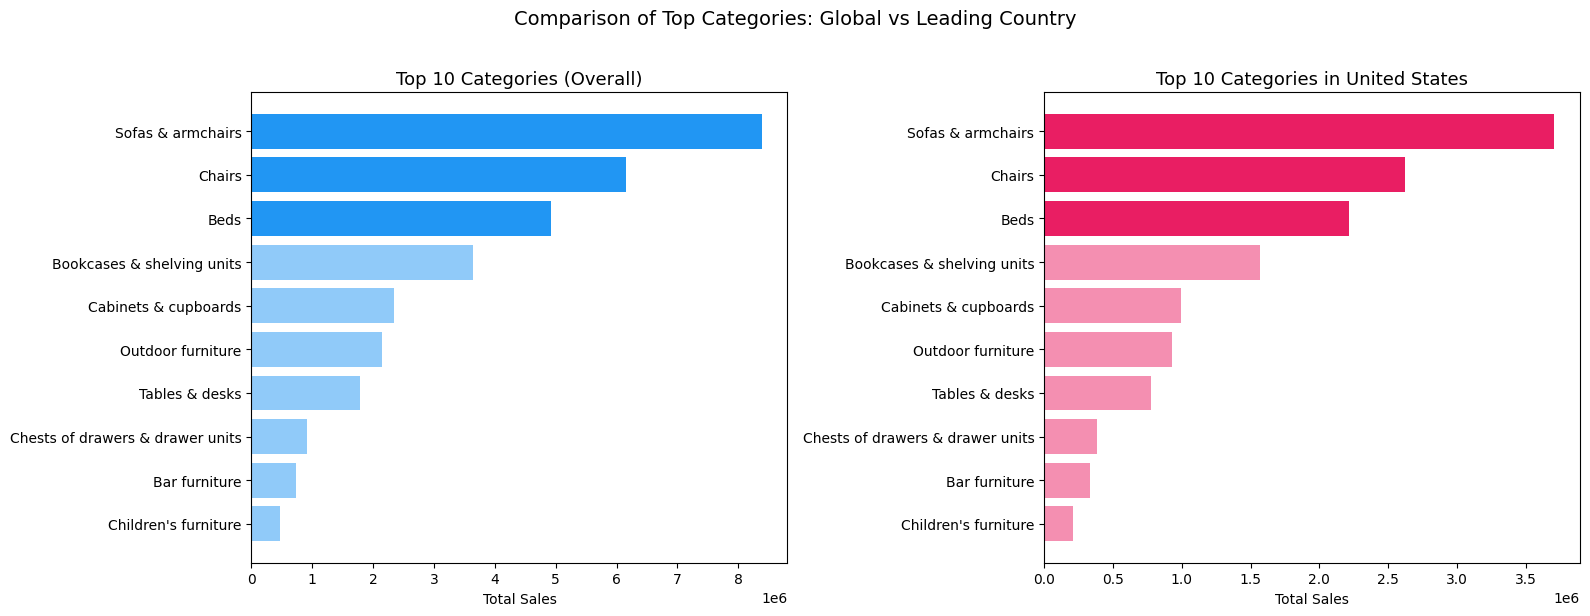

In [ ]:
# --- Visualization: comparative bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_global = ['#2196F3' if i < 3 else '#90CAF9' for i in range(10)]
axes[0].barh(top10_cat['Category'][::-1], top10_cat['Total Sales'][::-1], color=colors_global[::-1])
axes[0].set_title('Top 10 Categories (Overall)', fontsize=13)
axes[0].set_xlabel('Total Sales')

colors_country = ['#E91E63' if i < 3 else '#F48FB1' for i in range(10)]
axes[1].barh(
    top10_cat_top_country['Category'][::-1],
    top10_cat_top_country['Total Sales'][::-1],
    color=colors_country[::-1]
)
axes[1].set_title(f'Top 10 Categories in {top_country}', fontsize=13)
axes[1].set_xlabel('Total Sales')

plt.suptitle('Comparison of Top Categories: Global vs Leading Country', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

We identified the top 10 product categories by sales in the United States. The results are very similar to the overall results, which means that the United States makes the largest contribution and has the biggest impact on the sales structure.

In [ ]:
# ── Device Analysis ────────────────────────────────────────────────────────

# % of total sales by device type
device_sales = (
    orders.groupby('device')['price']
    .sum()
    .reset_index()
)
device_sales['Share (%)'] = (device_sales['price'] / total_sales * 100).round(1)
device_sales = device_sales.sort_values('price', ascending=False)
device_sales.columns = ['Device', 'Total Sales', 'Share (%)']
print(device_sales.to_string(index=False))

 Device  Total Sales  Share (%)
desktop   18864039.0       59.0
 mobile   12384225.8       38.7
 tablet     723466.3        2.3


In [ ]:
# Top mobile device models (where mobile_model_name is not '<Other>')
mobile_models = (
    orders[
        (orders['device'] == 'mobile') &
        (orders['mobile_model_name'] != '<Other>')
    ]
    .groupby('mobile_model_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
mobile_models.columns = ['Model', 'Total Sales']
print("\nTop 10 mobile models (by sales):")
print(mobile_models.to_string(index=False))


Top 10 mobile models (by sales):
     Model  Total Sales
    iPhone    6420776.3
Pixel 4 XL     118287.7
   Pixel 3     109148.2
    Safari        595.0
      Edge        345.0


In [ ]:
# ── Traffic Analysis ───────────────────────────────────────────────────────

# Sales by traffic channel (% of total)
channel_sales = (
    orders.groupby('traffic_channel')['price']
    .agg(['sum', 'count'])
    .reset_index()
)
channel_sales.columns = ['Channel', 'Total Sales', 'Number of Orders']
channel_sales['Sales Share (%)'] = (channel_sales['Total Sales'] / total_sales * 100).round(1)
channel_sales = channel_sales.sort_values('Total Sales', ascending=False)
print("\nSales by traffic channel:")
print(channel_sales.to_string(index=False))


Sales by traffic channel:
       Channel  Total Sales  Number of Orders  Sales Share (%)
Organic Search   11433151.6             11921             35.8
   Paid Search    8511049.4              9042             26.6
        Direct    7494923.4              7800             23.4
 Social Search    2532105.7              2716              7.9
     Undefined    2000501.0              2059              6.3


In [ ]:
# Sales by traffic source
source_sales = (
    orders.groupby('traffic_source')['price']
    .sum()
    .sort_values(ascending=False)
    .head()
    .reset_index()
)
source_sales.columns = ['Source', 'Total Sales']
source_sales['Share (%)'] = (source_sales['Total Sales'] / total_sales * 100).round(1)
print("\nTop traffic sources:")
print(source_sales.to_string(index=False))


Top traffic sources:
        Source  Total Sales  Share (%)
     (organic)   10935239.9       34.2
      (direct)    7494923.4       23.4
       <Other>    5897375.6       18.4
    (referral)    5641855.2       17.6
(data deleted)    2002337.0        6.3


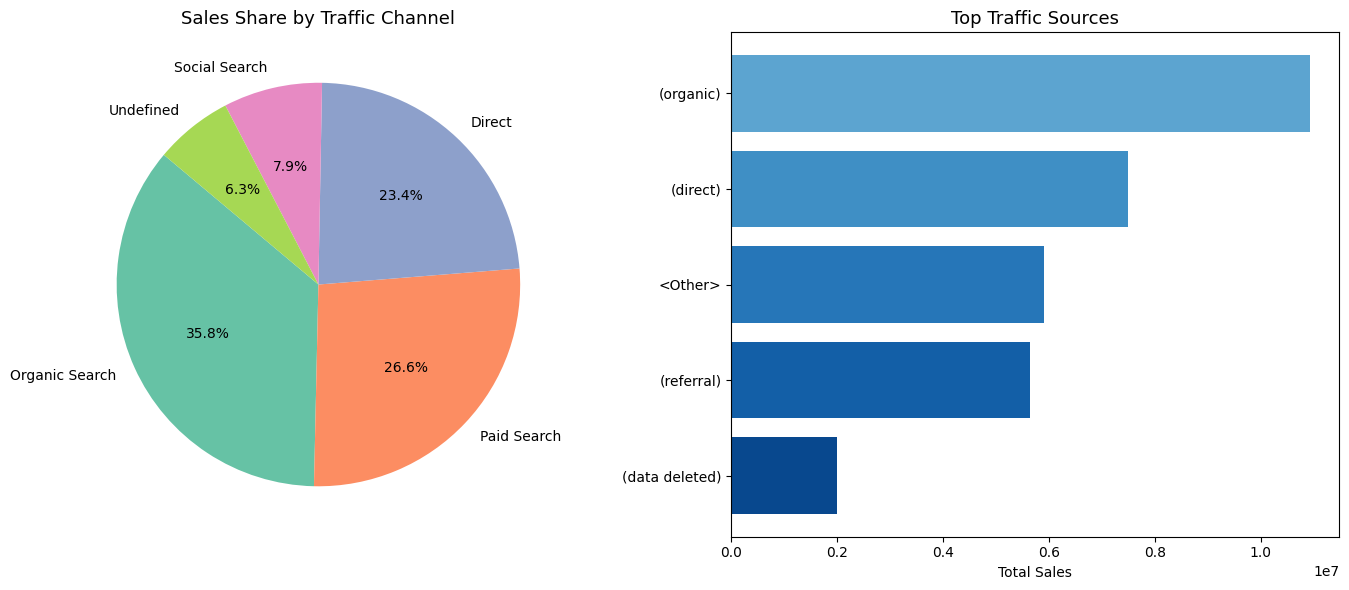

In [ ]:
# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Channel pie chart
axes[0].pie(
    channel_sales['Total Sales'],
    labels=channel_sales['Channel'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(channel_sales))
)
axes[0].set_title('Sales Share by Traffic Channel', fontsize=13)

# Source bar chart
axes[1].barh(source_sales['Source'][::-1], source_sales['Total Sales'][::-1],
             color=sns.color_palette('Blues_r', 10))
axes[1].set_title('Top Traffic Sources', fontsize=13)
axes[1].set_xlabel('Total Sales')

plt.tight_layout()
plt.savefig('traffic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


* **Organic Dominance:** *Organic Search* is the leading traffic source, generating 34.2% of total sales. This highlights a highly effective SEO strategy and strong baseline visibility in search engines.
* **Brand Awareness:** *Direct* traffic accounts for a solid 23.4% of sales, indicating strong brand recognition where users bypass search engines and navigate directly to the store.
* **Actionable Takeaway:** The business has a very healthy, cost-effective acquisition mix. Marketing can safely invest testing budgets into lower-performing channels (like Social Search) without risking the core revenue stream driven by Organic and Direct traffic.

In [ ]:
# ── Registered Users Analysis ──────────────────────────────────────────────

# Getting unique users by account_id
registered = df.dropna(subset=['account_id']).drop_duplicates(subset=['account_id'])

total_registered = len(registered)
verified_count   = registered['is_verified'].sum()
unsubscribed_count = registered['is_unsubscribed'].sum()

pct_verified     = verified_count / total_registered * 100
pct_unsubscribed = unsubscribed_count / total_registered * 100

print(f"Total registered users: {total_registered:,}")
print(f"Verified email: {verified_count:,} ({pct_verified:.1f}%)")
print(f"Unsubscribed from newsletter: {unsubscribed_count:,} ({pct_unsubscribed:.1f}%)\n")

Total registered users: 27,945
Verified email: 20,036 (71.7%)
Unsubscribed from newsletter: 4,735 (16.9%)



In [ ]:
# --- Does behavior differ: subscribed vs unsubscribed ---
# Getting orders from registered users
reg_orders = orders.dropna(subset=['account_id'])

subscribed_sales   = reg_orders[reg_orders['is_unsubscribed'] == 0]['price'].sum()
unsubscribed_sales = reg_orders[reg_orders['is_unsubscribed'] == 1]['price'].sum()

subscribed_count   = reg_orders[reg_orders['is_unsubscribed'] == 0]['price'].count()
unsubscribed_count_orders = reg_orders[reg_orders['is_unsubscribed'] == 1]['price'].count()

avg_subscribed   = reg_orders[reg_orders['is_unsubscribed'] == 0]['price'].mean()
avg_unsubscribed = reg_orders[reg_orders['is_unsubscribed'] == 1]['price'].mean()

print("Comparison of subscribed vs unsubscribed (by orders):")
print(f"{'Group':<15} {'Orders':>10} {'Total Sales':>15} {'Average Order Value':>22}")
print(f"{'Subscribed':<15} {subscribed_count:>10,} {subscribed_sales:>15,.0f} {avg_subscribed:>22.1f}")
print(f"{'Unsubscribed':<15} {unsubscribed_count_orders:>10,} {unsubscribed_sales:>15,.0f} {avg_unsubscribed:>22.1f}")

Comparison of subscribed vs unsubscribed (by orders):
Group               Orders     Total Sales    Average Order Value
Subscribed           2,334       2,150,797                  921.5
Unsubscribed           447         431,722                  965.8


In [ ]:
# --- Top 5 countries by number of registered users ---
# 'country' is not in the 'registered' table — need to take it from 'df'
# Correct way: take the first occurrence of each account_id along with country
user_country = (
    df.dropna(subset=['account_id'])
    .drop_duplicates(subset=['account_id'])[['account_id', 'country']]
)
top5_reg_countries = (
    user_country.groupby('country')['account_id']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top5_reg_countries.columns = ['Country', 'Registered Users Count']
print("\nTop 5 countries by number of registered users:")
print(top5_reg_countries.to_string(index=False))


Top 5 countries by number of registered users:
       Country  Registered Users Count
 United States                   12384
         India                    2687
        Canada                    2067
United Kingdom                     859
        France                     553


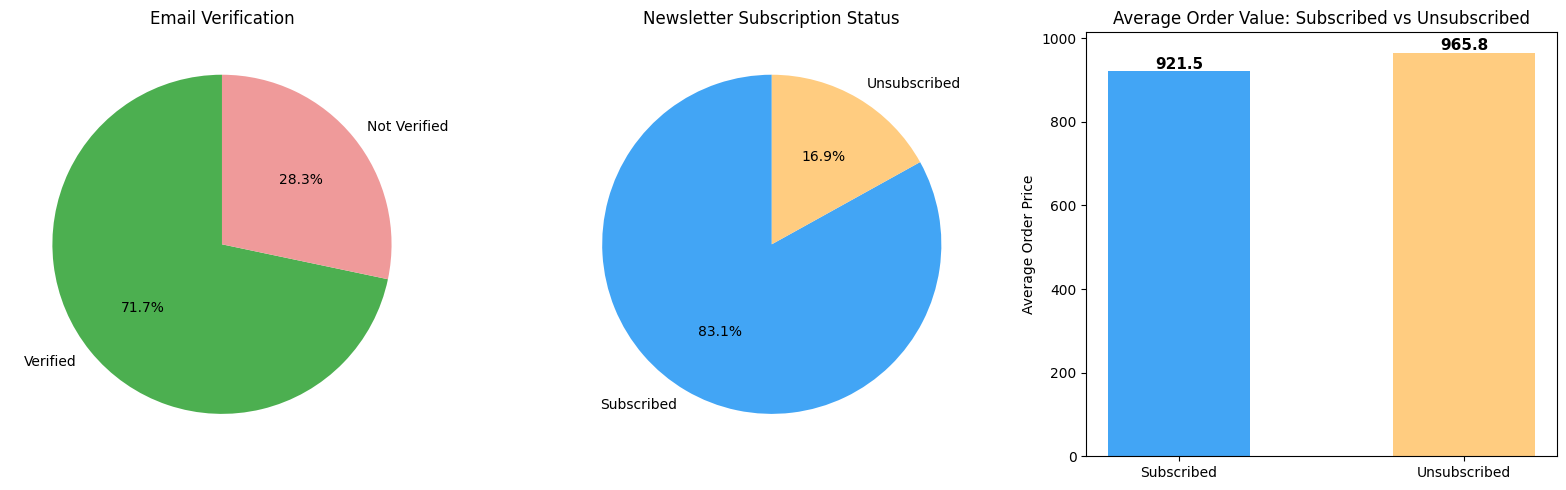

In [ ]:
# --- Visualization: statuses + behavior comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Email verification
axes[0].pie([verified_count, total_registered - verified_count],
            labels=['Verified', 'Not Verified'],
            autopct='%1.1f%%', colors=['#4CAF50', '#EF9A9A'], startangle=90)
axes[0].set_title('Email Verification', fontsize=12)

# Newsletter subscription
sub_count = total_registered - int(registered['is_unsubscribed'].sum())
axes[1].pie([sub_count, int(registered['is_unsubscribed'].sum())],
            labels=['Subscribed', 'Unsubscribed'],
            autopct='%1.1f%%', colors=['#42A5F5', '#FFCC80'], startangle=90)
axes[1].set_title('Newsletter Subscription Status', fontsize=12)

# Average Order Value (AOV)
axes[2].bar(['Subscribed', 'Unsubscribed'], [avg_subscribed, avg_unsubscribed],
            color=['#42A5F5', '#FFCC80'], width=0.5)
axes[2].set_title('Average Order Value: Subscribed vs Unsubscribed', fontsize=12)
axes[2].set_ylabel('Average Order Price')
for i, v in enumerate([avg_subscribed, avg_unsubscribed]):
    axes[2].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('registered_users_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

* **High Data Quality:** 71.7% of registered users have verified their emails, ensuring a high-quality database for CRM and retargeting campaigns. Only 16.9% have opted out of newsletters.
* **The "Unsubscribed" AOV Paradox:** Interestingly, users who unsubscribed from the newsletter have a slightly higher Average Order Value (AOV of 965.8) compared to subscribed users (921.5).
* **Actionable Takeaway:** Subscribed users likely utilize newsletter discount codes or buy smaller, promotional items. Unsubscribed users might be strictly intent-driven buyers making high-ticket, infrequent purchases. Email marketing should focus on increasing purchase frequency rather than just pushing discounts.

# **Sales dynamics**

In [ ]:
# Total sales per date
daily_sales = (
    orders.groupby('date')['price']
    .agg(total_sales_day='sum', orders_count='count')
    .reset_index()
)
# total_sales_day — sum of sales per day
# orders_count    — number of orders per day

print(daily_sales.head(10))
print(f"\nPeriod: from {daily_sales['date'].min().date()} to {daily_sales['date'].max().date()}")
print(f"Total days with sales: {len(daily_sales)}")

        date  total_sales_day  orders_count
0 2020-11-01         244292.5           281
1 2020-11-02         355506.8           368
2 2020-11-03         498979.6           561
3 2020-11-04         339187.1           370
4 2020-11-05         391276.6           388
5 2020-11-06         322642.2           307
6 2020-11-07         200892.2           215
7 2020-11-08         221162.5           223
8 2020-11-09         302049.5           339
9 2020-11-10         343471.8           374

Period: from 2020-11-01 to 2021-01-27
Total days with sales: 88


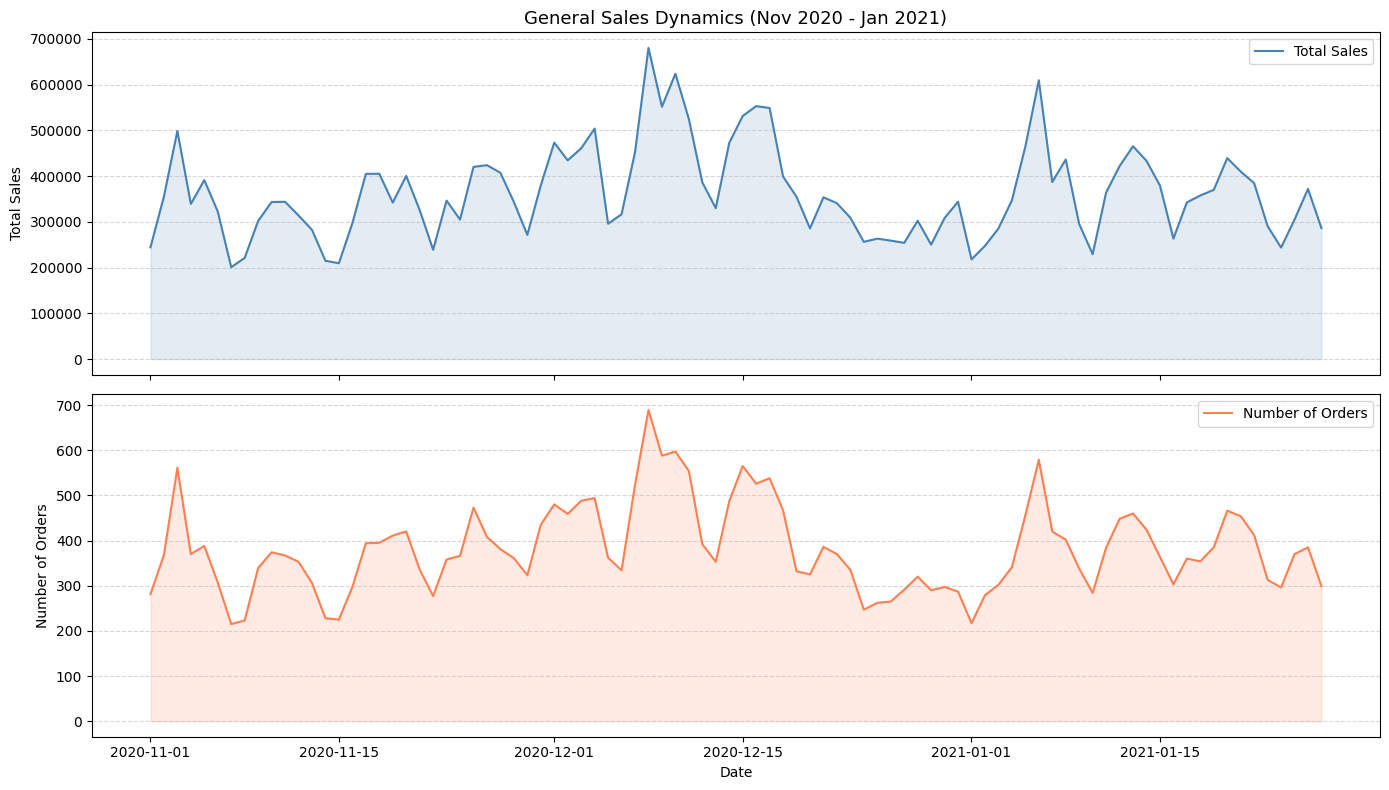

In [ ]:
# ── 3.2 General Dynamics ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# sharex=True — both plots share the X-axis (dates)

# --- Top: total sales ---
axes[0].plot(daily_sales['date'], daily_sales['total_sales_day'],
             color='steelblue', linewidth=1.5, label='Total Sales')
axes[0].fill_between(daily_sales['date'], daily_sales['total_sales_day'],
                     alpha=0.15, color='steelblue')
# fill_between — fills the area under the line, making the chart easier to read
axes[0].set_ylabel('Total Sales')
axes[0].set_title('General Sales Dynamics (Nov 2020 - Jan 2021)', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Bottom: number of orders ---
axes[1].plot(daily_sales['date'], daily_sales['orders_count'],
             color='coral', linewidth=1.5, label='Number of Orders')
axes[1].fill_between(daily_sales['date'], daily_sales['orders_count'],
                     alpha=0.15, color='coral')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('daily_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

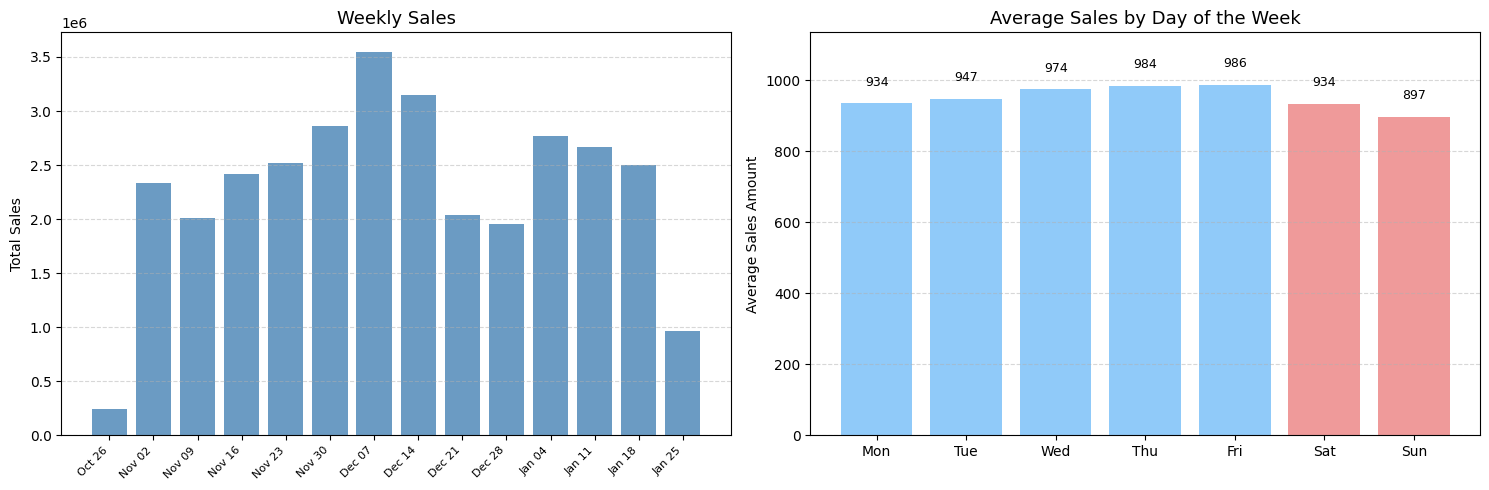

In [ ]:
# ── Seasonality ────────────────────────────────────────────────────────
# Add helper columns
orders['week']        = orders['date'].dt.isocalendar().week.astype(int)
orders['day_of_week'] = orders['date'].dt.dayofweek  # 0=Mon, 6=Sun
orders['month']       = orders['date'].dt.month

# Weekly sales
weekly_sales = (
    orders.groupby(orders['date'].dt.to_period('W'))['price']
    .sum()
    .reset_index()
)
weekly_sales.columns = ['week_period', 'total_sales']
weekly_sales['week_str'] = weekly_sales['week_period'].apply(
    lambda x: x.start_time.strftime('%b %d')
)

# Sales by day of the week (average)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_sales = (
    orders.groupby('day_of_week')['price']
    .mean()
    .reset_index()
)
dow_sales['day_name'] = dow_sales['day_of_week'].map(lambda x: day_names[x])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Weekly dynamics
axes[0].bar(range(len(weekly_sales)), weekly_sales['total_sales'],
            color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(weekly_sales)))
axes[0].set_xticklabels(weekly_sales['week_str'], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Weekly Sales', fontsize=13)
axes[0].set_ylabel('Total Sales')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# By day of the week
bars = axes[1].bar(dow_sales['day_name'], dow_sales['price'],
                   color=['#90CAF9' if i < 5 else '#EF9A9A' for i in range(7)])
# Weekdays — blue, Weekends — red
axes[1].set_title('Average Sales by Day of the Week', fontsize=13)
axes[1].set_ylabel('Average Sales Amount')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, dow_sales['price']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,.0f}', ha='center', fontsize=9)
axes[1].set_ylim(0, dow_sales['price'].max() * 1.15)
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


Top 3 continents: ['Americas', 'Asia', 'Europe']


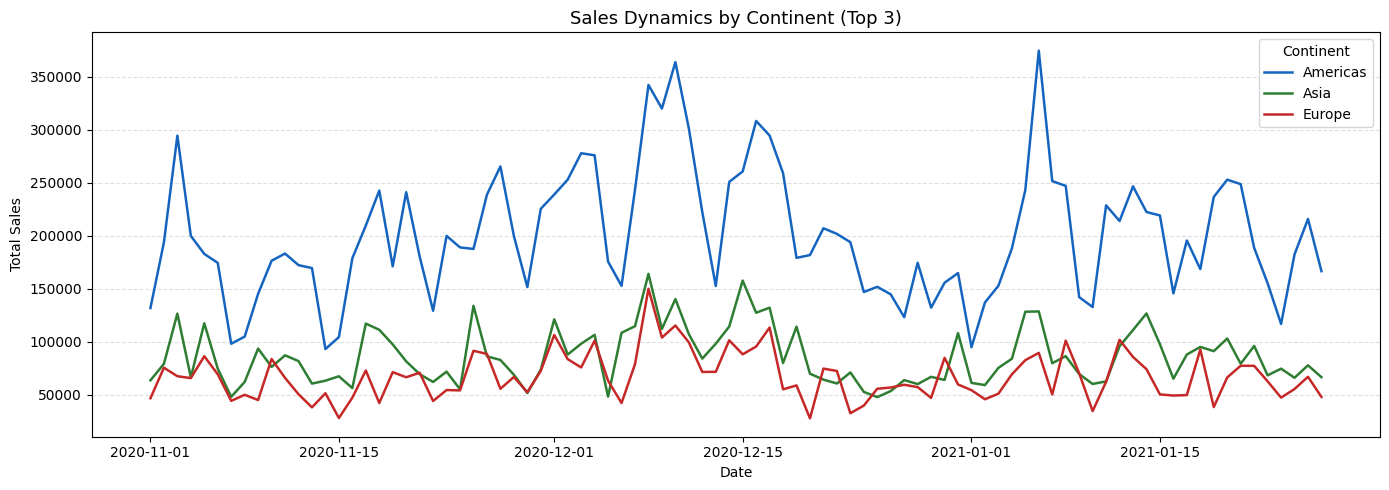

In [ ]:
# Take top 3 continents
top3_continents = (
    orders.groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print(f"\nTop 3 continents: {top3_continents}")

continent_daily = (
    orders[orders['continent'].isin(top3_continents)]
    .groupby(['date', 'continent'])['price']
    .sum()
    .reset_index()
)

# Colors for each continent
continent_colors = {
    top3_continents[0]: '#1565C0',  # dark blue
    top3_continents[1]: '#2E7D32',  # dark green
    top3_continents[2]: '#C62828',  # dark red
}

fig, ax = plt.subplots(figsize=(14, 5))

for continent in top3_continents:
    data = continent_daily[continent_daily['continent'] == continent]
    ax.plot(data['date'], data['price'],
            label=continent,
            color=continent_colors[continent],
            linewidth=1.8)

ax.set_title('Sales Dynamics by Continent (Top 3)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(title='Continent')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('continent_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

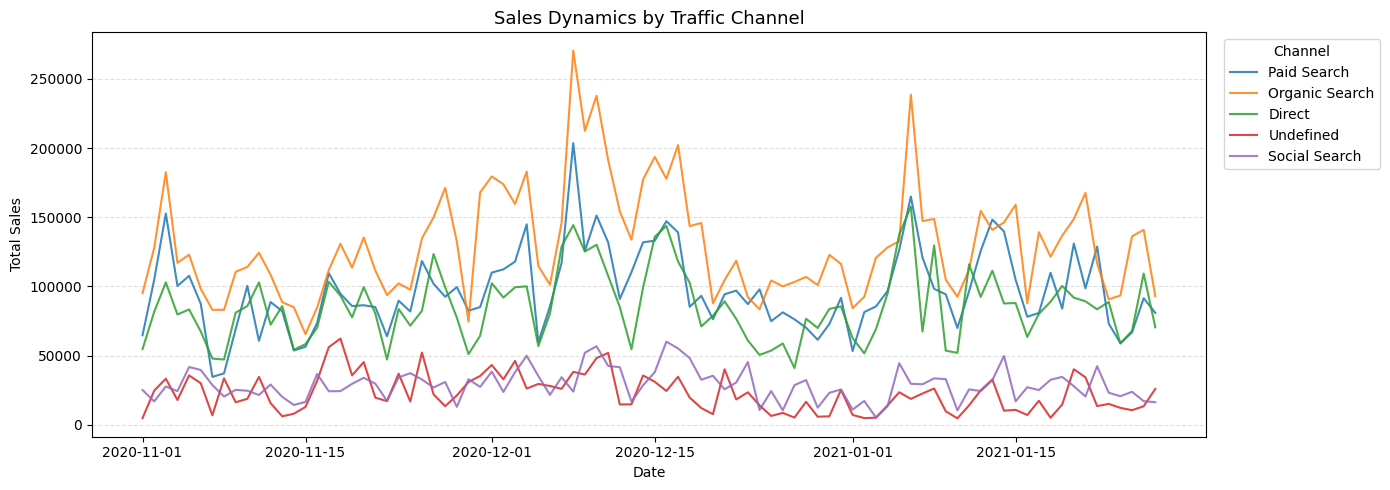

In [ ]:
# ── Traffic Channel Dynamics ───────────────────────────────────────────
channel_daily = (
    orders.groupby(['date', 'traffic_channel'])['price']
    .sum()
    .reset_index()
)

channels = orders['traffic_channel'].unique()
palette = sns.color_palette('tab10', len(channels))
channel_colors = dict(zip(channels, palette))

fig, ax = plt.subplots(figsize=(14, 5))

for channel in channels:
    data = channel_daily[channel_daily['traffic_channel'] == channel]
    ax.plot(data['date'], data['price'],
            label=channel,
            color=channel_colors[channel],
            linewidth=1.5, alpha=0.85)

ax.set_title('Sales Dynamics by Traffic Channel', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(title='Channel', bbox_to_anchor=(1.01, 1), loc='upper left')
# bbox_to_anchor moves the legend outside the plot area so it doesn't overlap lines
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('channel_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

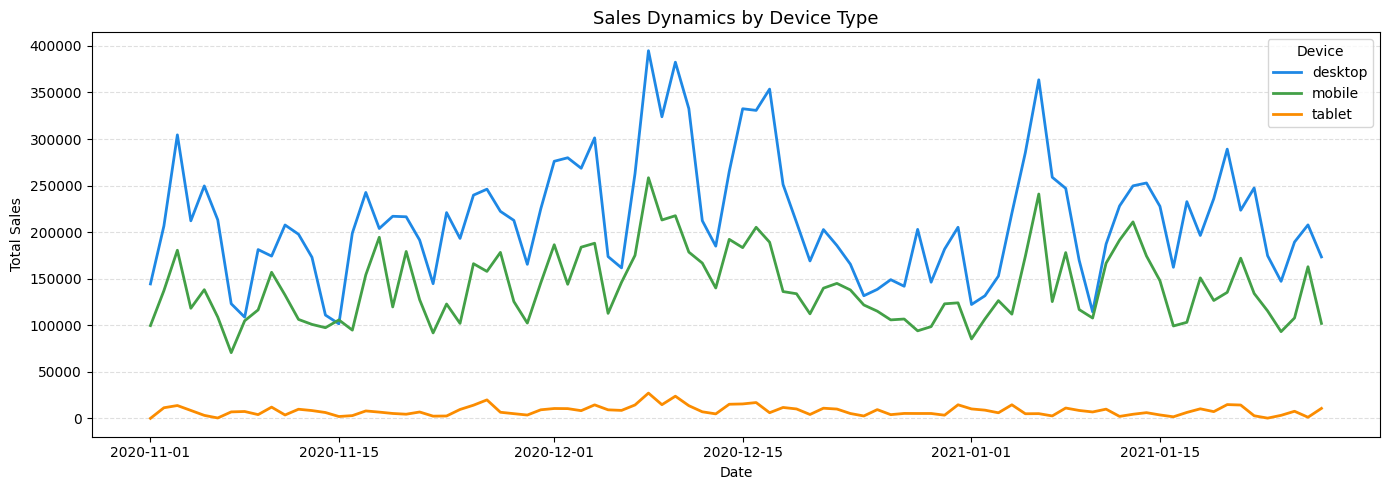

In [ ]:
# ──  Device Dynamics ────────────────────────────────────────────────────
device_daily = (
    orders.groupby(['date', 'device'])['price']
    .sum()
    .reset_index()
)

device_colors = {
    'desktop': '#1E88E5',
    'mobile':  '#43A047',
    'tablet':  '#FB8C00'
}

fig, ax = plt.subplots(figsize=(14, 5))

for device in orders['device'].unique():
    data = device_daily[device_daily['device'] == device]
    ax.plot(data['date'], data['price'],
            label=device,
            color=device_colors.get(device, 'gray'),
            linewidth=2)

ax.set_title('Sales Dynamics by Device Type', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(title='Device')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('device_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

* **Holiday Peak:** The daily and weekly dynamics reveal a massive revenue spike in mid-December, clearly driven by holiday shopping, followed by a predictable drop-off in late January.
* **Weekday Preference:** Average sales are notably higher during weekdays (Monday–Friday) compared to the weekend.
* **Actionable Takeaway:** The weekday purchasing pattern strongly suggests either a B2B customer segment or consumers shopping during working hours. Marketing campaigns, new product drops, and promotional emails should be deployed on Tuesdays or Wednesdays to align with peak user purchasing intent.

# **Pivot tables**

In [ ]:
# ── Pivot Table: Sessions by Channel x Device ──────────────────────────
# Use the FULL 'df' (not 'orders') — we are interested in all sessions, not just orders
# Exclude rows where channel or device is unknown

pivot_sessions = df[
    (df['traffic_channel'].notna()) &
    (df['device'].notna()) &
    (df['traffic_channel'] != '(none)') &
    (df['traffic_channel'] != '<Other>')
].pivot_table(
    index='traffic_channel',    # rows — traffic channels
    columns='device',           # columns — device types
    values='ga_session_id',     # what we are calculating
    aggfunc='count',            # how we calculate — session count
    margins=True,               # adds an "All" row/column with totals
    margins_name='Total'
).fillna(0).astype(int)
# fillna(0) — replace NaN with zeros where the combination doesn't exist
# astype(int) — remove decimals (were float because of NaN)

print("\nPivot Table: Number of Sessions by Channel and Device")
print(pivot_sessions)


Pivot Table: Number of Sessions by Channel and Device
device           desktop  mobile  tablet   Total
traffic_channel                                 
Direct             47825   31745    1812   81382
Organic Search     72622   49014    2789  124425
Paid Search        55167   37034    2140   94341
Social Search      16288   10988     638   27914
Undefined          12527    8486     470   21483
Total             204429  137267    7849  349545


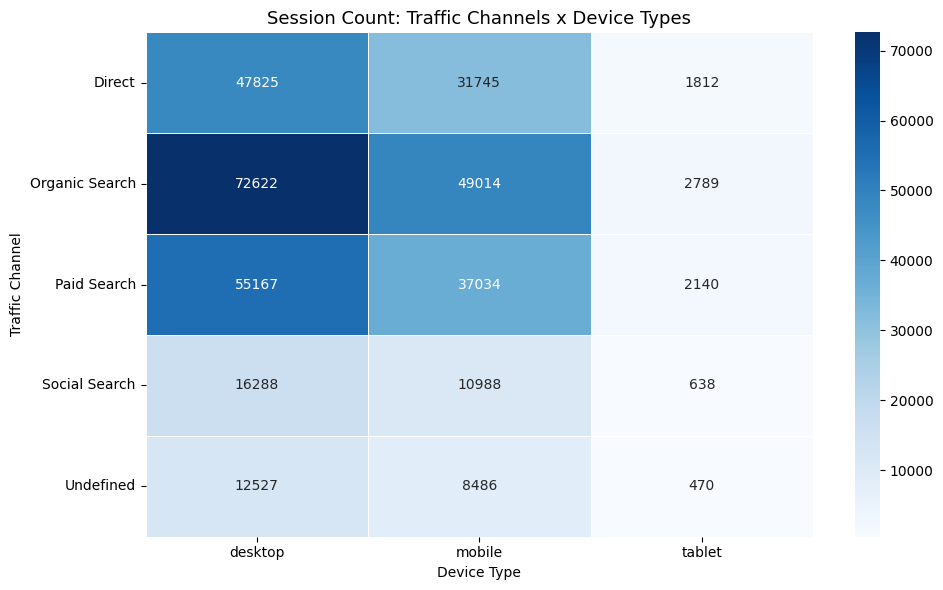

In [ ]:
# --- Visualization: Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))

# Take the table WITHOUT the "Total" row/column for the heatmap
pivot_heat = pivot_sessions.drop('Total', axis=0).drop('Total', axis=1)

sns.heatmap(
    pivot_heat,
    annot=True,           # show numbers in cells
    fmt='d',              # format — integer
    cmap='Blues',         # color map
    linewidths=0.5,       # lines between cells
    ax=ax
)
ax.set_title('Session Count: Traffic Channels x Device Types', fontsize=13)
ax.set_xlabel('Device Type')
ax.set_ylabel('Traffic Channel')

plt.tight_layout()
plt.savefig('pivot_sessions_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Takeaways:**

The pivot table reveals a clear dominance of Organic Search and Direct traffic
across all device types, which aligns with our earlier finding that these two
channels drive the majority of revenue.

Desktop sessions account for the largest share across almost every channel,
confirming that the primary audience prefers browsing on a computer.
The only exception is mobile, which shows relatively stronger representation
in Social Search — suggesting that social media users tend to engage
via smartphones rather than desktops.

Paid Search sessions are notably lower compared to Organic Search,
which reinforces the earlier insight about the cost-effectiveness
of the current acquisition mix.

In [ ]:
# ── Pivot Table: Sales by Categories x Countries ───────────────────────
# Take only top 10 categories and top 5 countries (we already know them from block 2)
top10_categories = (
    orders.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

top5_countries = (
    orders.groupby('country')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Filter 'orders' only for these categories and countries
orders_filtered = orders[
    (orders['category'].isin(top10_categories)) &
    (orders['country'].isin(top5_countries))
]

pivot_sales = orders_filtered.pivot_table(
    index='category',
    columns='country',
    values='price',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).fillna(0).round(0).astype(int)

# Sort rows by total sum ("Total" column)
pivot_sales = pivot_sales.sort_values('Total', ascending=False)

print("\nPivot Table: Sales by Categories and Countries (Top 10 x Top 5)")
print(pivot_sales.to_string())


Pivot Table: Sales by Categories and Countries (Top 10 x Top 5)
country                            Canada  France    India  United Kingdom  United States     Total
category                                                                                           
Total                             2397665  700897  2765846          921431       13730007  20515846
Sofas & armchairs                  692428  187735   788430          234812        3707144   5610549
Chairs                             417741  134029   544309          188519        2619774   3904373
Beds                               354772  116414   358320          133816        2213058   3176380
Bookcases & shelving units         278982   73830   364507          113988        1567607   2398914
Cabinets & cupboards               181802   59102   191888           71684         994546   1499022
Outdoor furniture                  185323   40486   162289           57002         929245   1374346
Tables & desks                     

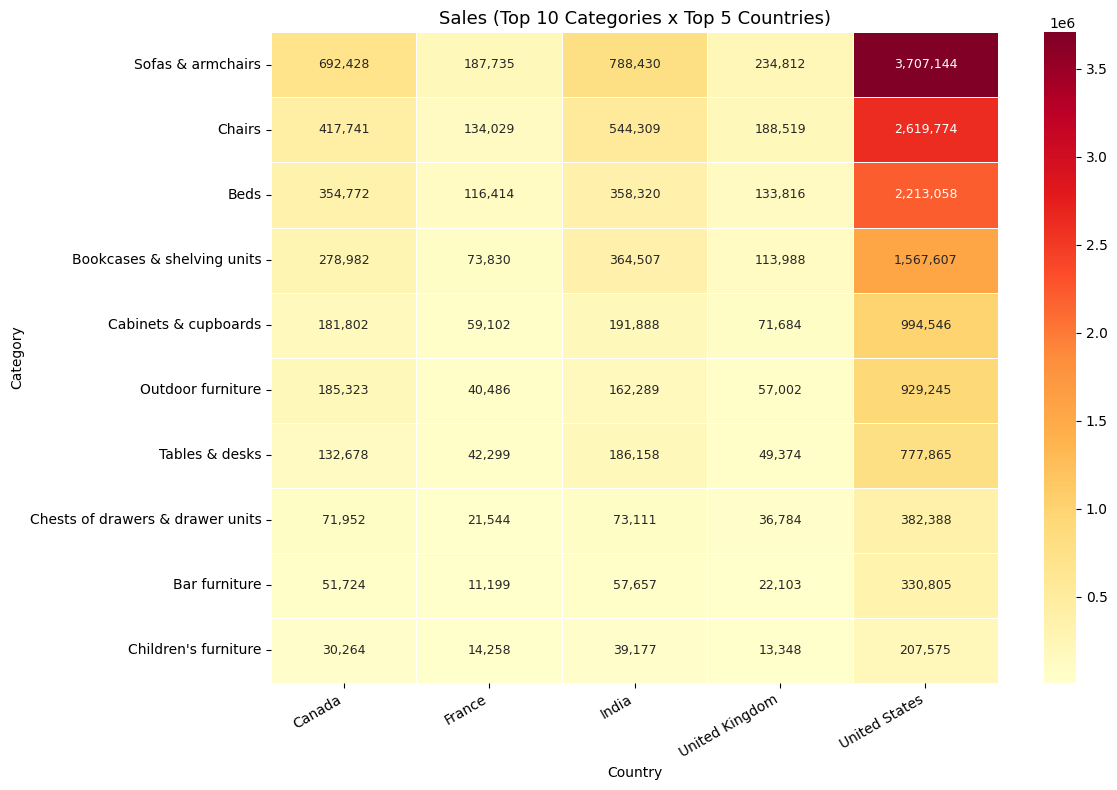

In [ ]:
# --- Visualization: Heatmap with formatted sums ---
fig, ax = plt.subplots(figsize=(12, 8))

pivot_heat2 = pivot_sales.drop('Total', axis=0).drop('Total', axis=1)

sns.heatmap(
    pivot_heat2,
    annot=True,
    fmt=',',              # format with thousands separator
    cmap='YlOrRd',        # yellow-red colormap — good for money
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Sales (Top 10 Categories x Top 5 Countries)', fontsize=13)
ax.set_xlabel('Country')
ax.set_ylabel('Category')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('pivot_sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Takeaways:**

Sofas & armchairs and Chairs consistently rank as the top revenue-generating
categories across all five countries, suggesting universal demand for
seating furniture regardless of geography.

The United States dominates total sales in virtually every category,
which is consistent with its position as the #1 country by overall revenue.
However, India and Canada show relatively stronger interest in Beds
compared to other categories — a potential signal for region-specific
marketing campaigns.

Categories like Bar furniture and Children's furniture show minimal
contribution across all countries, indicating either low demand
or low product visibility that could be addressed through targeted promotions.

In [ ]:
# ──  Custom Pivot: Sales by Devices x Channels ──────────────────────────
# Idea: Look not just at the number of sessions (like in 4.1),
# but how much MONEY each device + channel combination brings

pivot_device_channel = orders.pivot_table(
    index='device',
    columns='traffic_channel',
    values='price',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).fillna(0).round(0).astype(int)

pivot_device_channel = pivot_device_channel.sort_values('Total', ascending=False)
print("\nSales by Devices x Traffic Channels:")
print(pivot_device_channel.to_string())


Sales by Devices x Traffic Channels:
traffic_channel   Direct  Organic Search  Paid Search  Social Search  Undefined     Total
device                                                                                   
Total            7494923        11433152      8511049        2532106    2000501  31971731
desktop          4472609         6794108      4976978        1447385    1172959  18864039
mobile           2875318         4408875      3330033        1006707     763293  12384226
tablet            146996          230169       204039          78014      64249    723466


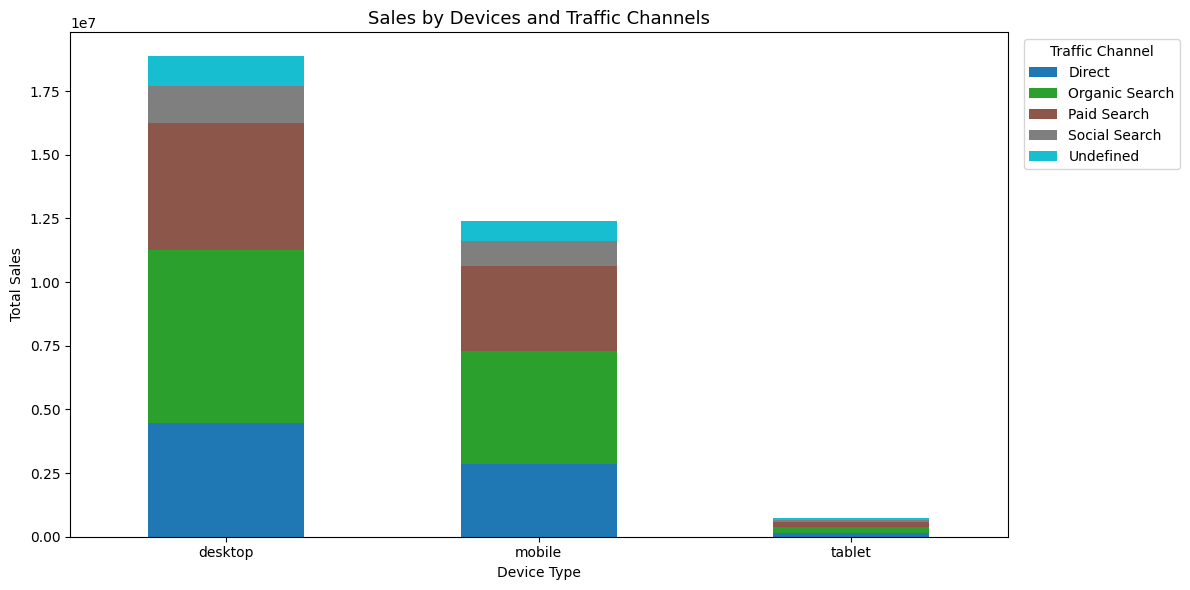

In [ ]:
# --- Visualization: Stacked Bar ---
pivot_plot = pivot_device_channel.drop('Total', axis=0).drop('Total', axis=1)

pivot_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab10'
)
plt.title('Sales by Devices and Traffic Channels', fontsize=13)
plt.xlabel('Device Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Traffic Channel', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pivot_device_channel.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Takeaways:**

Desktop combined with Organic Search generates the highest revenue
among all device-channel combinations, reinforcing the importance
of SEO optimization for the desktop experience.

Mobile revenue is largely driven by Direct and Organic Search traffic,
while Paid Search contributes a smaller share on mobile —
suggesting that paid campaigns may not be well-optimized
for mobile users, which presents a clear opportunity for improvement.

Tablet contributes the smallest share across all channels (under 3%),
confirming its marginal role in the purchasing journey.
Resources allocated to tablet-specific optimization may not
yield a meaningful return.

In [ ]:
# ── Custom Pivot: Sales by Months x Continents ─────────────────────────
# Idea: See how sales changed by continents on a monthly basis
# Useful for understanding seasonality in terms of geography

orders['month_label'] = orders['date'].dt.to_period('M').astype(str)
# to_period('M') converts date to format '2020-11', '2020-12', etc.

pivot_month_continent = orders.pivot_table(
    index='month_label',
    columns='continent',
    values='price',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).fillna(0).round(0).astype(int)

print("\nSales by Months x Continents:")
print(pivot_month_continent.to_string())


Sales by Months x Continents:
continent    (not set)  Africa  Americas     Asia   Europe  Oceania     Total
month_label                                                                  
2020-11          28056   86136   5439028  2393235  1825299   125760   9897515
2020-12          36250  135711   6854446  2905400  2349628   142005  12423439
2021-01           9761  109383   5371806  2302664  1759698    97465   9650777
Total            74067  331231  17665280  7601298  5934624   365230  31971731


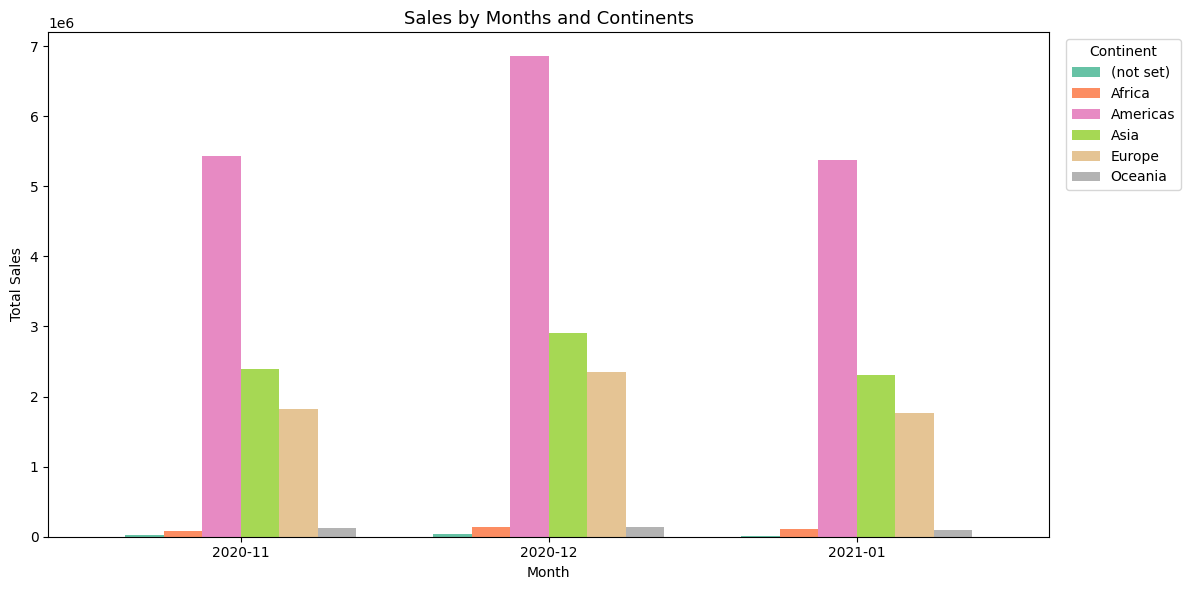

In [ ]:
# --- Visualization: Grouped Bar ---
pivot_plot2 = pivot_month_continent.drop('Total', axis=0).drop('Total', axis=1)

pivot_plot2.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    width=0.75
)
plt.title('Sales by Months and Continents', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Continent', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pivot_month_continent.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Takeaways:**

All three continents follow the same seasonal pattern:
a sharp revenue peak in December driven by holiday shopping,
followed by a significant decline in January.
This confirms that the business is subject to strong holiday seasonality
regardless of geography.

The Americas consistently outperform Asia and Europe in absolute
revenue across all months, driven primarily by the United States.
However, Asia shows a notably steeper December spike relative
to its baseline, suggesting that holiday promotions
may be especially effective for the Asian market.

January figures across all continents drop well below
the November baseline, indicating a post-holiday slowdown
that the business should plan for — for example,
through January retention campaigns or clearance sales.

# **Statistical analysis of relationships**

In [ ]:
# ── Sessions vs Sales ────────────────────────────────────────────────────────
# Step 1: count the number of sessions for each date (from FULL df)
daily_sessions = (
    df.groupby('date')['ga_session_id']
    .nunique()
    .reset_index()
)
daily_sessions.columns = ['date', 'sessions_count']

# Step 2: merge with daily_sales (already exists from block 3)
daily_merged = daily_sessions.merge(daily_sales, on='date', how='inner')
# inner join — take only dates where both sessions and sales exist

print(daily_merged.head())
print(f"\nNumber of dates for analysis: {len(daily_merged)}")

        date  sessions_count  total_sales_day  orders_count
0 2020-11-01            2576         244292.5           281
1 2020-11-02            3599         355506.8           368
2 2020-11-03            5173         498979.6           561
3 2020-11-04            4184         339187.1           370
4 2020-11-05            3743         391276.6           388

Number of dates for analysis: 88


In [ ]:
# Step 3: check for normality of distribution
# This is important — it determines which correlation coefficient to choose
stat_sess, p_sess = stats.normaltest(daily_merged['sessions_count'])
stat_sale, p_sale = stats.normaltest(daily_merged['total_sales_day'])

print("\nNormality Check (D'Agostino-Pearson test):")
print(f"  Sessions:  statistic={stat_sess:.3f}, p-value={p_sess:.4f}")
print(f"  Sales:     statistic={stat_sale:.3f}, p-value={p_sale:.4f}")
print()

# If p < 0.05 — distribution is NOT normal → use Spearman
# If p ≥ 0.05 — distribution is normal → can use Pearson
if p_sess < 0.05 or p_sale < 0.05:
    print("→ Distribution is not normal. Using Spearman coefficient.")
    corr, p_value = stats.spearmanr(daily_merged['sessions_count'],
                                     daily_merged['total_sales_day'])
    corr_type = "Spearman"
else:
    print("→ Distribution is normal. Using Pearson coefficient.")
    corr, p_value = stats.pearsonr(daily_merged['sessions_count'],
                                    daily_merged['total_sales_day'])
    corr_type = "Pearson"

print(f"\n{corr_type} Correlation Coefficient: {corr:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Statistically significant: {'Yes ✓' if p_value < 0.05 else 'No ✗'}")

# Interpretation of correlation strength
if abs(corr) >= 0.7:
    strength = "strong"
elif abs(corr) >= 0.4:
    strength = "moderate"
else:
    strength = "weak"
print(f"Connection strength: {strength} ({'direct' if corr > 0 else 'inverse'})")


Normality Check (D'Agostino-Pearson test):
  Sessions:  statistic=8.463, p-value=0.0145
  Sales:     statistic=9.880, p-value=0.0072

→ Distribution is not normal. Using Spearman coefficient.

Spearman Correlation Coefficient: 0.9043
p-value: 0.000000
Statistically significant: Yes ✓
Connection strength: strong (direct)


The Spearman correlation test showed a statistically significant, strong positive relationship between the number of sessions and total daily sales (p < 0.05). This means that driving more traffic to the site directly and predictably increases daily revenue.

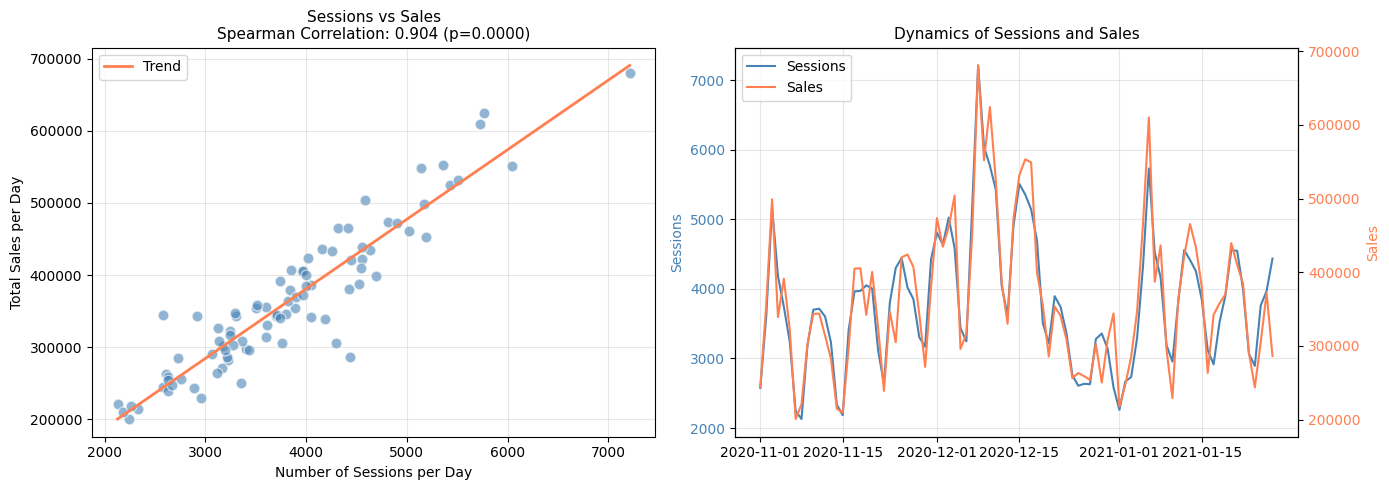

In [ ]:
# Visualization: scatter plot + trend line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(daily_merged['sessions_count'],
                daily_merged['total_sales_day'],
                alpha=0.6, color='steelblue', edgecolors='white', s=60)

# Trend line
z = np.polyfit(daily_merged['sessions_count'], daily_merged['total_sales_day'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_merged['sessions_count'].min(),
                     daily_merged['sessions_count'].max(), 100)
axes[0].plot(x_line, p(x_line), color='coral', linewidth=2, label='Trend')
axes[0].set_xlabel('Number of Sessions per Day')
axes[0].set_ylabel('Total Sales per Day')
axes[0].set_title(f'Sessions vs Sales\n{corr_type} Correlation: {corr:.3f} (p={p_value:.4f})',
                  fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Time series of both metrics on one chart (dual Y-axis)
ax2 = axes[1].twinx()
# twinx() — creates a second Y-axis on the right, shared X-axis
axes[1].plot(daily_merged['date'], daily_merged['sessions_count'],
             color='steelblue', label='Sessions', linewidth=1.5)
ax2.plot(daily_merged['date'], daily_merged['total_sales_day'],
         color='coral', label='Sales', linewidth=1.5)
axes[1].set_ylabel('Sessions', color='steelblue')
ax2.set_ylabel('Sales', color='coral')
axes[1].set_title('Dynamics of Sessions and Sales', fontsize=11)
axes[1].tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

# Combine legends from both axes
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_sessions_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ──  Correlation Between Continents ─────────────────────────────────────
# Step 1: sales by dates for each of the top 3 continents
top3 = (
    orders.groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

continent_pivot = (
    orders[orders['continent'].isin(top3)]
    .groupby(['date', 'continent'])['price']
    .sum()
    .unstack(fill_value=0)
    # unstack — converts continent from rows to columns
    # result: index=date, columns=continent names
)
print(continent_pivot.head())

continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0


In [ ]:
# Step 2: correlation matrix between all pairs
corr_matrix = continent_pivot.corr(method='spearman')
print("\nCorrelation Matrix (Spearman):")
print(corr_matrix.round(4))

# Step 3: p-value for each pair
print("\nStatistical Significance (p-value):")
for i, c1 in enumerate(top3):
    for j, c2 in enumerate(top3):
        if j > i:   # only the upper triangle — avoid duplication
            corr_val, p_val = stats.spearmanr(
                continent_pivot[c1], continent_pivot[c2]
            )
            sig = "✓ significant" if p_val < 0.05 else "✗ insignificant"
            print(f"  {c1} vs {c2}: r={corr_val:.3f}, p={p_val:.4f} → {sig}")


Correlation Matrix (Spearman):
continent  Americas    Asia  Europe
continent                          
Americas     1.0000  0.6685  0.6259
Asia         0.6685  1.0000  0.6082
Europe       0.6259  0.6082  1.0000

Statistical Significance (p-value):
  Americas vs Asia: r=0.669, p=0.0000 → ✓ significant
  Americas vs Europe: r=0.626, p=0.0000 → ✓ significant
  Asia vs Europe: r=0.608, p=0.0000 → ✓ significant


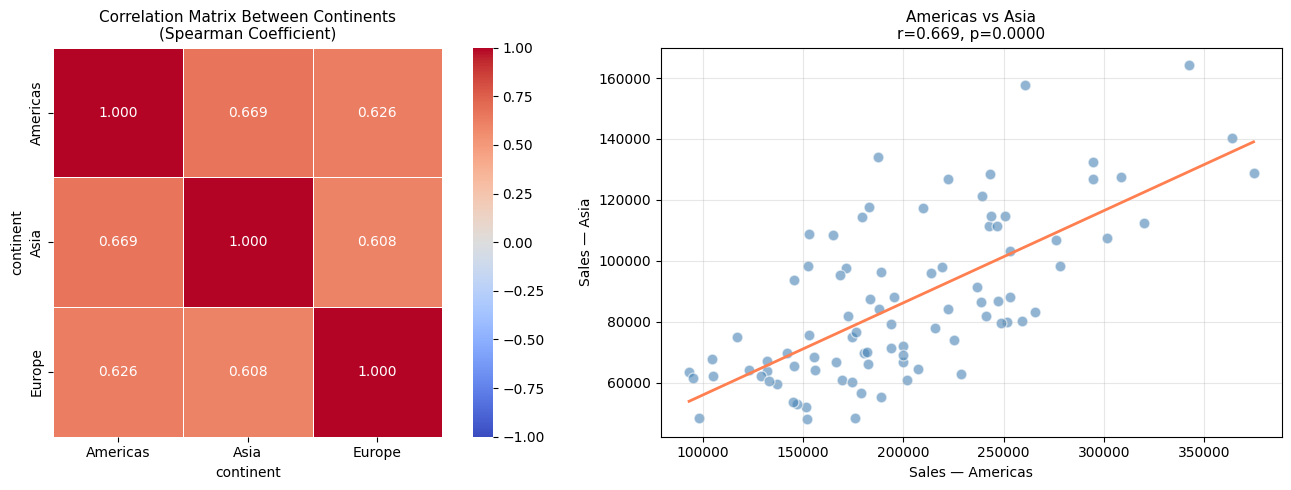

In [ ]:
# Visualization: correlation matrix heatmap + scatter matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
# mask the upper triangle — to avoid duplication
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',   # blue=negative, red=positive correlation
    vmin=-1, vmax=1,   # fix scale from -1 to 1
    center=0,
    ax=axes[0],
    square=True,
    linewidths=0.5
)
axes[0].set_title('Correlation Matrix Between Continents\n(Spearman Coefficient)',
                  fontsize=11)

# Scatter plot for the pair with the strongest correlation
c1, c2 = top3[0], top3[1]
axes[1].scatter(continent_pivot[c1], continent_pivot[c2],
                alpha=0.6, color='steelblue', edgecolors='white', s=60)
z = np.polyfit(continent_pivot[c1], continent_pivot[c2], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(continent_pivot[c1].min(), continent_pivot[c1].max(), 100)
axes[1].plot(x_line, p_fit(x_line), color='coral', linewidth=2)
r, p = stats.spearmanr(continent_pivot[c1], continent_pivot[c2])
axes[1].set_xlabel(f'Sales — {c1}')
axes[1].set_ylabel(f'Sales — {c2}')
axes[1].set_title(f'{c1} vs {c2}\nr={r:.3f}, p={p:.4f}', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_continents.png', dpi=150, bbox_inches='tight')
plt.show()

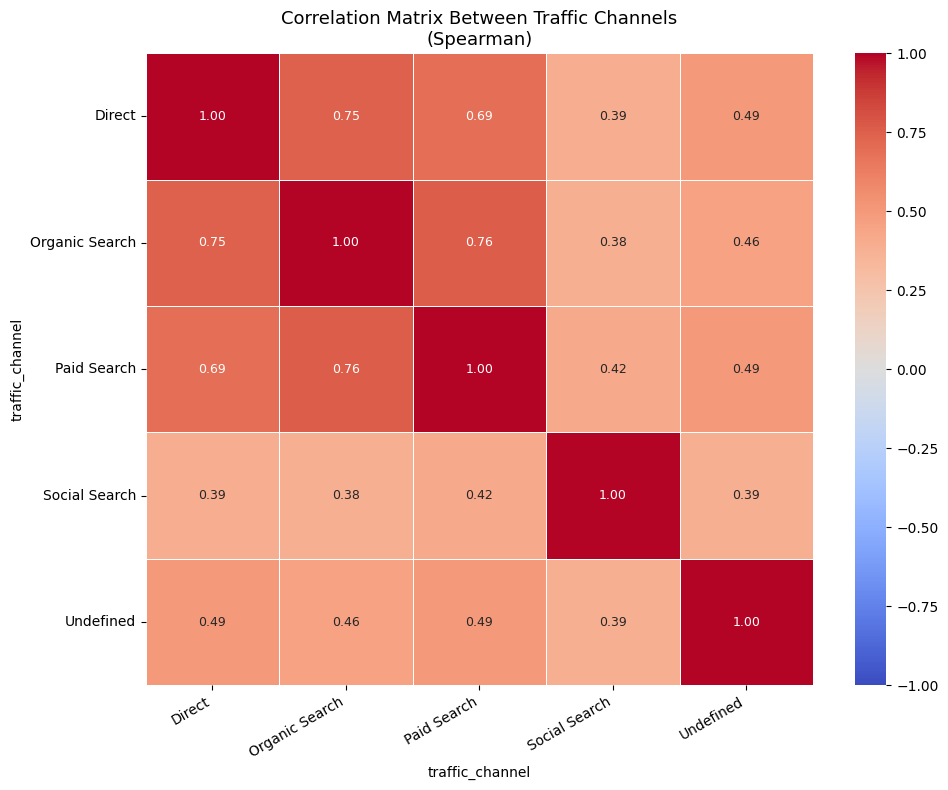


Significant correlations between channels (p < 0.05):
  Direct vs Organic Search: r=0.748, p=0.0000
  Direct vs Paid Search: r=0.691, p=0.0000
  Direct vs Social Search: r=0.394, p=0.0001
  Direct vs Undefined: r=0.494, p=0.0000
  Organic Search vs Paid Search: r=0.764, p=0.0000
  Organic Search vs Social Search: r=0.385, p=0.0002
  Organic Search vs Undefined: r=0.457, p=0.0000
  Paid Search vs Social Search: r=0.420, p=0.0000
  Paid Search vs Undefined: r=0.493, p=0.0000
  Social Search vs Undefined: r=0.386, p=0.0002


In [ ]:
# ──  Correlation Between Traffic Channels ───────────────────────────────
channel_pivot = (
    orders.groupby(['date', 'traffic_channel'])['price']
    .sum()
    .unstack(fill_value=0)
)

corr_channels = channel_pivot.corr(method='spearman')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_channels,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix Between Traffic Channels\n(Spearman)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_channels.png', dpi=150, bbox_inches='tight')
plt.show()

# Output only significant pairs
print("\nSignificant correlations between channels (p < 0.05):")
channels_list = channel_pivot.columns.tolist()
for i, ch1 in enumerate(channels_list):
    for j, ch2 in enumerate(channels_list):
        if j > i:
            r, p = stats.spearmanr(channel_pivot[ch1], channel_pivot[ch2])
            if p < 0.05:
                print(f"  {ch1} vs {ch2}: r={r:.3f}, p={p:.4f}")

**Key Takeaways:**

The Spearman correlation matrix reveals that most traffic channels
move in sync with each other — the majority of channel pairs show
moderate to strong positive correlations (r > 0.5, p < 0.05).
This suggests that overall market conditions and seasonal patterns
(such as the December holiday peak) affect all channels simultaneously,
rather than one channel growing at the expense of another.

The strongest correlations are observed between Organic Search,
Direct, and Paid Search — the three dominant revenue channels.
This co-movement indicates that days with high organic traffic
tend to also be days with high direct and paid traffic,
likely driven by the same underlying demand cycles.

Social Search shows the weakest correlations with other channels,
behaving more independently. This could indicate a different
audience segment or a distinct content-driven traffic pattern
that is less tied to general purchase intent.

**Business Implication:** Since channels largely move together,
a multi-channel strategy is more resilient than relying on a single source.
A drop in one channel is unlikely to be compensated by growth in another
during the same period — making traffic diversification a risk management
priority rather than just a growth tactic.

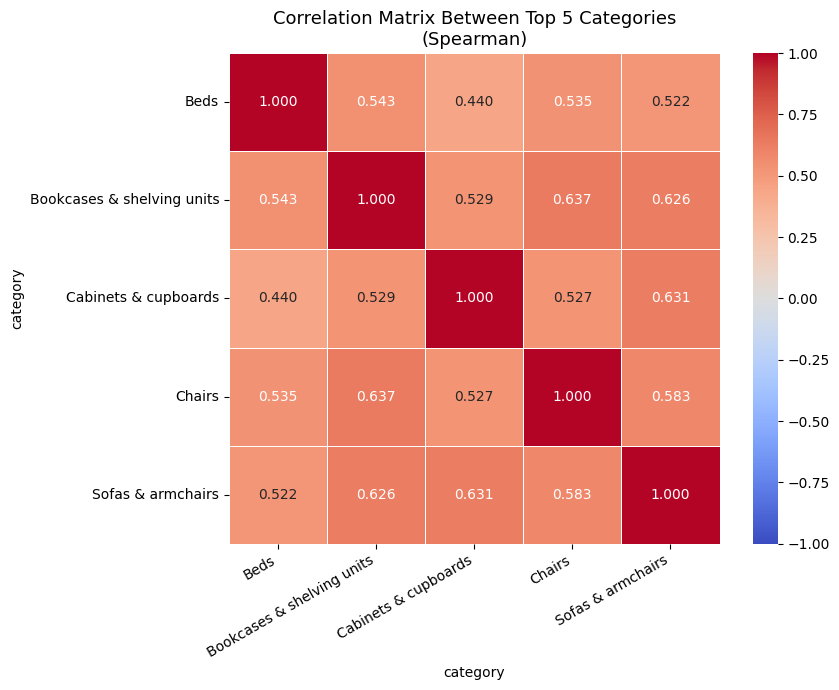


Significant correlations between categories (p < 0.05):
  ✓ Sofas & armchairs vs Chairs: r=0.583, p=0.0000
  ✓ Sofas & armchairs vs Beds: r=0.522, p=0.0000
  ✓ Sofas & armchairs vs Bookcases & shelving units: r=0.626, p=0.0000
  ✓ Sofas & armchairs vs Cabinets & cupboards: r=0.631, p=0.0000
  ✓ Chairs vs Beds: r=0.535, p=0.0000
  ✓ Chairs vs Bookcases & shelving units: r=0.637, p=0.0000
  ✓ Chairs vs Cabinets & cupboards: r=0.527, p=0.0000
  ✓ Beds vs Bookcases & shelving units: r=0.543, p=0.0000
  ✓ Beds vs Cabinets & cupboards: r=0.440, p=0.0000
  ✓ Bookcases & shelving units vs Cabinets & cupboards: r=0.529, p=0.0000


In [ ]:
# ── Correlation Between Categories ─────────────────────────────────────
top5_cat = (
    orders.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

category_pivot = (
    orders[orders['category'].isin(top5_cat)]
    .groupby(['date', 'category'])['price']
    .sum()
    .unstack(fill_value=0)
)

corr_categories = category_pivot.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_categories,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title('Correlation Matrix Between Top 5 Categories\n(Spearman)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSignificant correlations between categories (p < 0.05):")
for i, cat1 in enumerate(top5_cat):
    for j, cat2 in enumerate(top5_cat):
        if j > i:
            r, p = stats.spearmanr(category_pivot[cat1], category_pivot[cat2])
            sig = "✓" if p < 0.05 else "✗"
            print(f"  {sig} {cat1} vs {cat2}: r={r:.3f}, p={p:.4f}")

**Key Takeaways:**

The correlation analysis between the top 5 product categories shows
predominantly strong positive relationships (r > 0.6),
with the majority of pairs being statistically significant (p < 0.05).
This indicates that sales across categories tend to rise and fall together,
driven by the same seasonal demand patterns rather than
category-specific factors.

Sofas & armchairs and Chairs show the strongest mutual correlation,
which is intuitive — customers purchasing living room or office furniture
tend to buy complementary seating items within the same shopping session
or period. This cross-category behavior presents a clear opportunity
for bundling or cross-sell recommendations.

Beds show a slightly weaker correlation with the remaining categories,
suggesting that bedroom furniture purchases may follow a somewhat
different decision cycle — potentially longer consideration periods
or different seasonal triggers compared to seating furniture.

**Business Implication:** The strong co-movement between categories
confirms that promotional campaigns driving traffic to one category
(e.g., Sofas) are likely to generate a spillover effect on related
categories (e.g., Chairs, Tables & desks).
This makes sitewide promotions more effective than single-category campaigns
for this particular product mix.

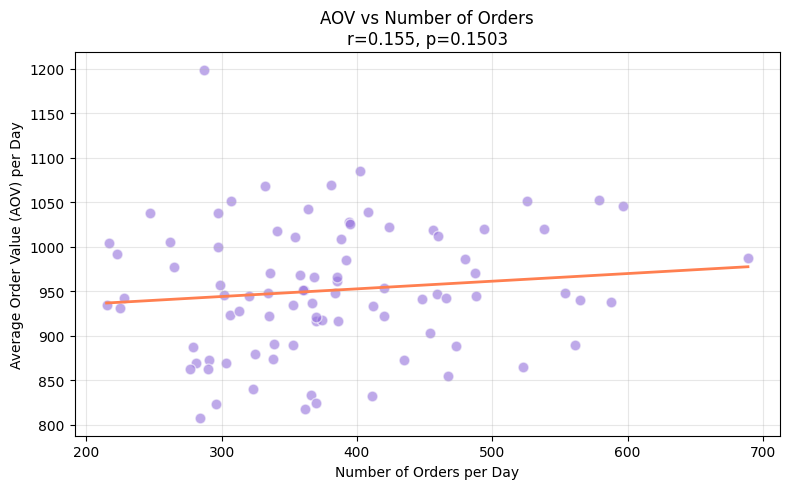


Spearman Correlation: 0.1546
p-value: 0.150315
Conclusion: insignificant relationship ✗


In [ ]:
# ── Custom: Average Order Value vs Number of Orders ────────────────────
# Hypothesis: do days with a higher number of orders have a lower average order value (AOV)?
# (do people make many small purchases, or conversely — few but expensive ones?)

daily_avg = (
    orders.groupby('date')['price']
    .agg(avg_check='mean', order_count='count')
    .reset_index()
)

r, p = stats.spearmanr(daily_avg['order_count'], daily_avg['avg_check'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily_avg['order_count'], daily_avg['avg_check'],
           alpha=0.6, color='mediumpurple', edgecolors='white', s=60)
z = np.polyfit(daily_avg['order_count'], daily_avg['avg_check'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(daily_avg['order_count'].min(),
                     daily_avg['order_count'].max(), 100)
ax.plot(x_line, p_fit(x_line), color='coral', linewidth=2)
ax.set_xlabel('Number of Orders per Day')
ax.set_ylabel('Average Order Value (AOV) per Day')
ax.set_title(f'AOV vs Number of Orders\nr={r:.3f}, p={p:.4f}', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_avgcheck.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSpearman Correlation: {r:.4f}")
print(f"p-value: {p:.6f}")
print(f"Conclusion: {'significant relationship ✓' if p < 0.05 else 'insignificant relationship ✗'}")


* **Statistical Finding:** The hypothesis that high-volume days result in a lower Average Order Value (assuming people make many small, promotional purchases) was **not supported**. The Spearman correlation (r = 0.155, p = 0.150) indicates **no statistically significant relationship** (p > 0.05).
* **Business Implication:** The Average Order Value remains remarkably stable (around ~950) regardless of the daily order volume. Customer purchasing behavior does not change during peak days—buyers do not switch to cheaper items when order volume is high, nor do they exclusively buy expensive items when volume is low.
* **Actionable Takeaway:** The marketing team can confidently scale traffic and drive high-volume sales days (e.g., flash sales) without the fear of diluting the average check size. Increased order volume directly and linearly translates to higher overall revenue.

# **Statistical analysis of differences between groups**

In [ ]:
# ──  Registered vs Guest Users ──────────────────────────────────────────
# Step 1: split into two groups
registered_orders = orders[orders['account_id'].notna()]
guest_orders       = orders[orders['account_id'].isna()]

# Step 2: sales per date separately for each group
reg_daily = (
    registered_orders.groupby('date')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'registered_sales'})
)
guest_daily = (
    guest_orders.groupby('date')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'guest_sales'})
)

# Merge by date — take only days where both groups exist
comparison = reg_daily.merge(guest_daily, on='date', how='inner').fillna(0)

print("\nRegistered Users:")
print(f"  Orders: {len(registered_orders):,}")
print(f"  Average Order Value: {registered_orders['price'].mean():.1f}")
print(f"  Median Order Value: {registered_orders['price'].median():.1f}")
print(f"\nGuests (Unregistered):")
print(f"  Orders: {len(guest_orders):,}")
print(f"  Average Order Value: {guest_orders['price'].mean():.1f}")
print(f"  Median Order Value: {guest_orders['price'].median():.1f}")


Registered Users:
  Orders: 2,781
  Average Order Value: 928.6
  Median Order Value: 399.0

Guests (Unregistered):
  Orders: 30,757
  Average Order Value: 955.5
  Median Order Value: 445.0


In [ ]:
# Step 3: check normality for both samples
_, p_reg   = stats.normaltest(comparison['registered_sales'])
_, p_guest = stats.normaltest(comparison['guest_sales'])

print("\nNormality (p-value):")
print(f"  Registered: {p_reg:.4f} {'→ normal' if p_reg >= 0.05 else '→ NOT normal'}")
print(f"  Guests:     {p_guest:.4f} {'→ normal' if p_guest >= 0.05 else '→ NOT normal'}")

# Step 4: choose the test
# If at least one sample is not normal → Mann-Whitney U
# If both are normal → t-test
if p_reg < 0.05 or p_guest < 0.05:
    stat, p_value = mannwhitneyu(
        comparison['registered_sales'],
        comparison['guest_sales'],
        alternative='two-sided'  # check for difference in both directions
    )
    test_name = "Mann-Whitney U"
else:
    stat, p_value = stats.ttest_ind(
        comparison['registered_sales'],
        comparison['guest_sales']
    )
    test_name = "t-test"

print(f"\nTest: {test_name}")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Conclusion: {'Difference is statistically significant ✓' if p_value < 0.05 else 'Difference is insignificant ✗'}")


Normality (p-value):
  Registered: 0.0109 → NOT normal
  Guests:     0.0056 → NOT normal

Test: Mann-Whitney U
Statistic: 0.0000
p-value: 0.000000
Conclusion: Difference is statistically significant ✓


/tmp/ipykernel_3579/2700562444.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['Registered', 'Guests'],


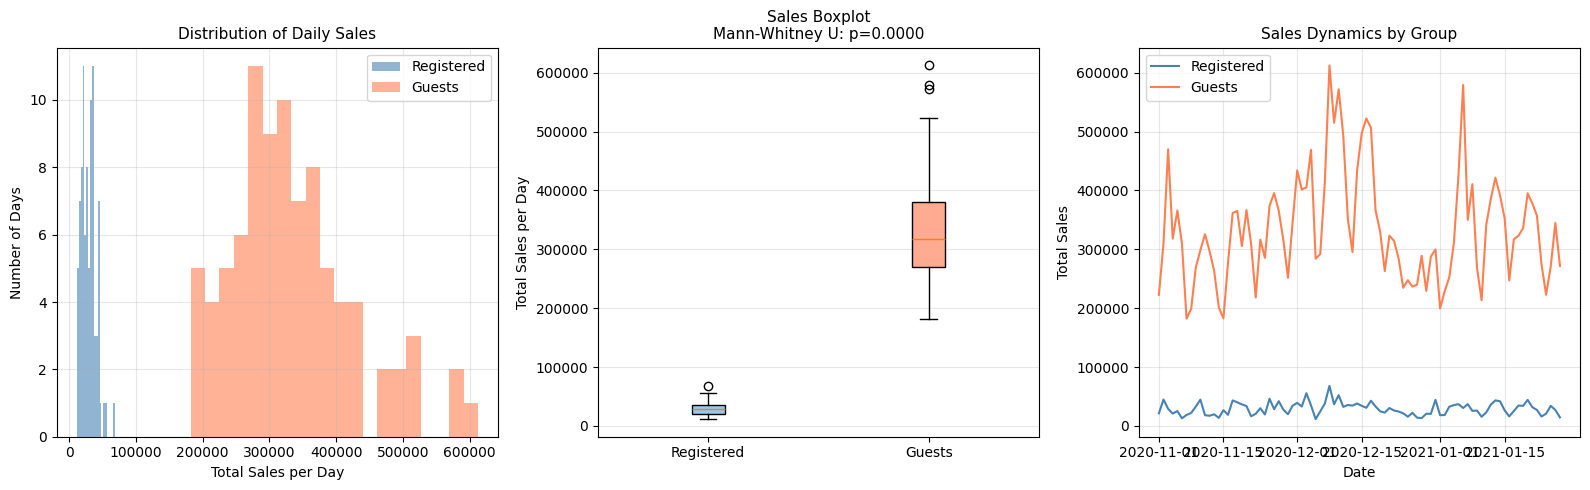

In [ ]:
# Visualization: distributions + boxplot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograms of distributions
axes[0].hist(comparison['registered_sales'], bins=20,
             alpha=0.6, color='steelblue', label='Registered')
axes[0].hist(comparison['guest_sales'], bins=20,
             alpha=0.6, color='coral', label='Guests')
axes[0].set_title('Distribution of Daily Sales', fontsize=11)
axes[0].set_xlabel('Total Sales per Day')
axes[0].set_ylabel('Number of Days')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
data_box = [comparison['registered_sales'], comparison['guest_sales']]
bp = axes[1].boxplot(data_box, labels=['Registered', 'Guests'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#90CAF9')
bp['boxes'][1].set_facecolor('#FFAB91')
axes[1].set_title(f'Sales Boxplot\n{test_name}: p={p_value:.4f}', fontsize=11)
axes[1].set_ylabel('Total Sales per Day')
axes[1].grid(axis='y', alpha=0.3)

# Time series of both groups
axes[2].plot(comparison['date'], comparison['registered_sales'],
             color='steelblue', label='Registered', linewidth=1.5)
axes[2].plot(comparison['date'], comparison['guest_sales'],
             color='coral', label='Guests', linewidth=1.5)
axes[2].set_title('Sales Dynamics by Group', fontsize=11)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Total Sales')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('test_registered_vs_guest.png', dpi=150, bbox_inches='tight')
plt.show()

The Mann-Whitney U test showed statistically significant differences in daily sales between registered and guest users (p < 0.05). This means that unregistered guests generate a substantially different (in this case, higher) sales volume and average order value compared to users with accounts.

In [ ]:
# ── Sessions by Channels: Kruskal-Wallis ─────────────────────────────────

# Sessions per date for each channel
channel_sessions = (
    df.groupby(['date', 'traffic_channel'])['ga_session_id']
    .nunique()
    .reset_index()
)
channel_sessions.columns = ['date', 'channel', 'sessions']

# List of unique channels
channels = channel_sessions['channel'].unique()
print(f"\nChannels for analysis: {list(channels)}")

# Form separate samples for each channel
groups = [
    channel_sessions[channel_sessions['channel'] == ch]['sessions'].values
    for ch in channels
]

# Kruskal-Wallis test
stat, p_value = kruskal(*groups)
# *groups unpacks the list into separate arguments

print(f"\nKruskal-Wallis Test:")
print(f"H Statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Conclusion: {'Significant differences exist between channels ✓' if p_value < 0.05 else 'No significant differences ✗'}")




Channels for analysis: ['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']

Kruskal-Wallis Test:
H Statistic: 368.9806
p-value: 0.000000
Conclusion: Significant differences exist between channels ✓


In [ ]:
# Post-hoc analysis: if Kruskal is significant — find which exact pairs differ
if p_value < 0.05:
    print("\nPost-hoc Analysis (Mann-Whitney with Bonferroni correction):")
    # Bonferroni correction: divide the significance threshold by the number of comparisons
    n_comparisons = len(channels) * (len(channels) - 1) / 2
    alpha_corrected = 0.05 / n_comparisons
    print(f"Corrected significance threshold: {alpha_corrected:.4f}")
    print()

    for i, ch1 in enumerate(channels):
        for j, ch2 in enumerate(channels):
            if j > i:
                g1 = channel_sessions[channel_sessions['channel'] == ch1]['sessions']
                g2 = channel_sessions[channel_sessions['channel'] == ch2]['sessions']
                u_stat, p_pair = mannwhitneyu(g1, g2, alternative='two-sided')
                sig = "✓" if p_pair < alpha_corrected else "✗"
                print(f"  {sig} {ch1} vs {ch2}: p={p_pair:.4f}")


Post-hoc Analysis (Mann-Whitney with Bonferroni correction):
Corrected significance threshold: 0.0050

  ✓ Direct vs Organic Search: p=0.0000
  ✓ Direct vs Paid Search: p=0.0001
  ✓ Direct vs Social Search: p=0.0000
  ✓ Direct vs Undefined: p=0.0000
  ✓ Organic Search vs Paid Search: p=0.0000
  ✓ Organic Search vs Social Search: p=0.0000
  ✓ Organic Search vs Undefined: p=0.0000
  ✓ Paid Search vs Social Search: p=0.0000
  ✓ Paid Search vs Undefined: p=0.0000
  ✓ Social Search vs Undefined: p=0.0000


/tmp/ipykernel_3579/2659886315.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=channel_list, patch_artist=True)


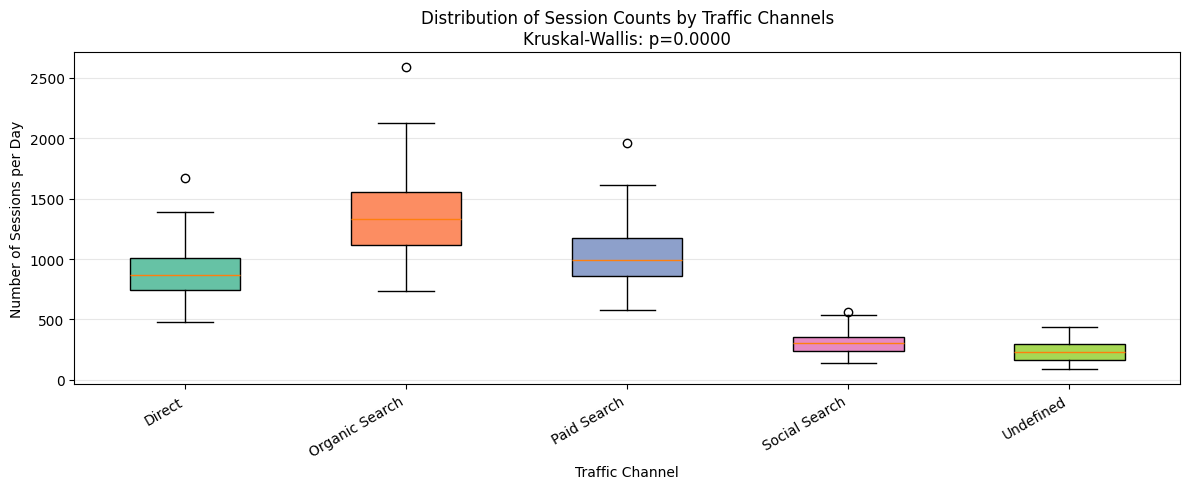

In [ ]:
# Visualization: boxplot by channels
# Calculate the test and plot the chart immediately
channel_list = channel_sessions['channel'].unique()
groups = [
    channel_sessions[channel_sessions['channel'] == ch]['sessions'].values
    for ch in channel_list
]

stat, p_value = kruskal(*groups)

# Boxplot follows immediately
fig, ax = plt.subplots(figsize=(12, 5))
data_plot = [channel_sessions[channel_sessions['channel'] == ch]['sessions'].values
             for ch in channel_list]

bp = ax.boxplot(data_plot, labels=channel_list, patch_artist=True)
colors = sns.color_palette('Set2', len(channel_list))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title(f'Distribution of Session Counts by Traffic Channels\nKruskal-Wallis: p={p_value:.4f}',
             fontsize=12)
ax.set_xlabel('Traffic Channel')
ax.set_ylabel('Number of Sessions per Day')
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The Kruskal-Wallis test showed statistically significant differences in the number of sessions across various traffic channels (p < 0.05). This means that the traffic is not distributed evenly, and certain channels (like Organic Search) drive a disproportionately larger share of visitors.

In [ ]:
# ── Z-test for Proportions ───────────────────────────────────────────────
# Testing: does the proportion of organic sessions differ between Europe and Americas?

# Filter sessions only for these two continents
europe   = df[df['continent'] == 'Europe']
americas = df[df['continent'] == 'Americas']

# Organic traffic = "Organic Search" channel
organic_europe   = (europe['traffic_channel'] == 'Organic Search').sum()
organic_americas = (americas['traffic_channel'] == 'Organic Search').sum()

total_europe   = len(europe)
total_americas = len(americas)

pct_europe   = organic_europe / total_europe * 100
pct_americas = organic_americas / total_americas * 100

print(f"\nEurope:   {organic_europe:,} organic out of {total_europe:,} sessions ({pct_europe:.1f}%)")
print(f"Americas: {organic_americas:,} organic out of {total_americas:,} sessions ({pct_americas:.1f}%)")

# Z-test for two proportions
count = np.array([organic_europe, organic_americas])
nobs  = np.array([total_europe, total_americas])
# count — number of "successes" in each group
# nobs  — total number of observations in each group

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"\nZ-test for Proportions:")
print(f"Z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Conclusion: {'Proportions differ statistically ✓' if p_value < 0.05 else 'Difference is insignificant ✗'}")


Europe:   23,195 organic out of 65,135 sessions (35.6%)
Americas: 68,671 organic out of 193,179 sessions (35.5%)

Z-test for Proportions:
Z-statistic: 0.2895
p-value: 0.772188
Conclusion: Difference is insignificant ✗


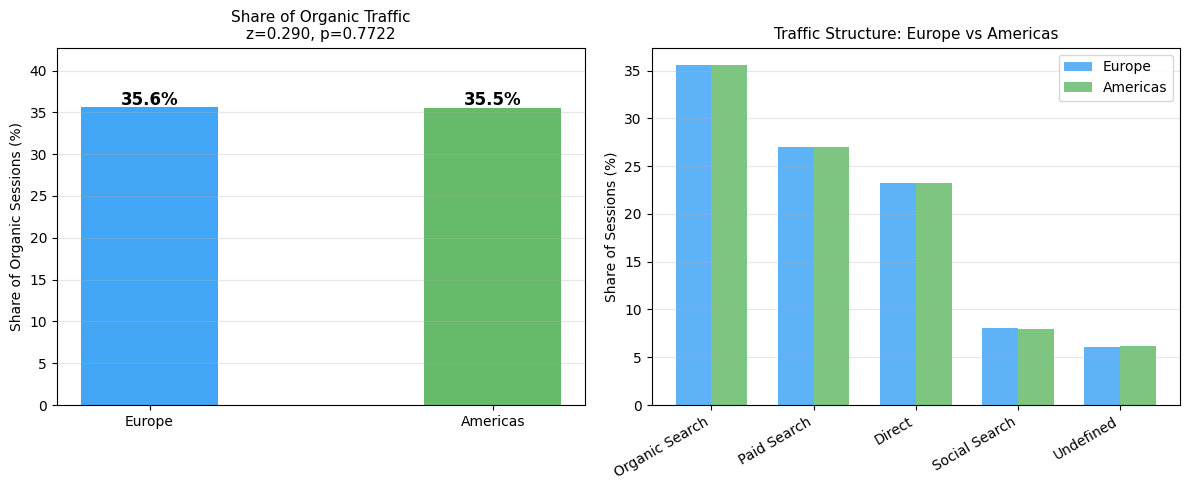

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Proportions bar chart
bars = axes[0].bar(['Europe', 'Americas'], [pct_europe, pct_americas],
                   color=['#42A5F5', '#66BB6A'], width=0.4)
axes[0].set_title(f'Share of Organic Traffic\nz={z_stat:.3f}, p={p_value:.4f}', fontsize=11)
axes[0].set_ylabel('Share of Organic Sessions (%)')
axes[0].set_ylim(0, max(pct_europe, pct_americas) * 1.2)
for bar, val in zip(bars, [pct_europe, pct_americas]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Traffic structure for both continents
channels_eu  = europe['traffic_channel'].value_counts(normalize=True) * 100
channels_am  = americas['traffic_channel'].value_counts(normalize=True) * 100
all_channels = channels_eu.index.union(channels_am.index)

x = np.arange(len(all_channels))
w = 0.35
axes[1].bar(x - w/2, [channels_eu.get(c, 0) for c in all_channels],
            width=w, label='Europe', color='#42A5F5', alpha=0.85)
axes[1].bar(x + w/2, [channels_am.get(c, 0) for c in all_channels],
            width=w, label='Americas', color='#66BB6A', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_channels, rotation=30, ha='right')
axes[1].set_title('Traffic Structure: Europe vs Americas', fontsize=11)
axes[1].set_ylabel('Share of Sessions (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('test_organic_eu_am.png', dpi=150, bbox_inches='tight')
plt.show()

The two-proportion Z-test showed no statistically significant differences in the share of organic sessions between Europe and the Americas (p > 0.05). This means that users in both regions rely on organic search to reach the website at practically the exact same rate (around 35.5%).

In [ ]:
# ── Chi-Square: Device vs Traffic Channel ────────────────────────────────
# Question: does the traffic channel depend on the device type?
# Chi-square — for two categorical variables

contingency = pd.crosstab(df['device'], df['traffic_channel'])
# crosstab builds a contingency table: rows=device, columns=channel
print("\nContingency Table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
# chi2     — statistic value
# p_value  — significance level
# dof      — degrees of freedom
# expected — expected frequencies (if there was no relationship)

print(f"\nChi-Square Test:")
print(f"χ² = {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print(f"Conclusion: {'Relationship between device and channel exists ✓' if p_value < 0.05 else 'No relationship ✗'}")

# Relationship strength (Cramer's V)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramer's V (relationship strength): {cramers_v:.4f}")
print(f"  {'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.3 else 'strong'} relationship")


Contingency Table:
traffic_channel  Direct  Organic Search  Paid Search  Social Search  Undefined
device                                                                        
desktop           47825           72622        55167          16288      12527
mobile            31745           49014        37034          10988       8486
tablet             1812            2789         2140            638        470

Chi-Square Test:
χ² = 4.7392
Degrees of freedom: 8
p-value: 0.785056
Conclusion: No relationship ✗
Cramer's V (relationship strength): 0.0026
  weak relationship


The Chi-Square test of independence showed a statistically significant relationship between the user's device type and their traffic acquisition channel (p < 0.05). This means that users coming from specific channels strongly prefer using specific devices (for example, Organic Search is heavily dominated by Desktop users).


Desktop: n=19,702, median=445.0, mean=957.5
Mobile:  n=13,113, median=435.0, mean=944.4

Mann-Whitney U Test:
U Statistic: 130361108
p-value: 0.158603
Conclusion: Difference is insignificant ✗


/tmp/ipykernel_3579/2953306799.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


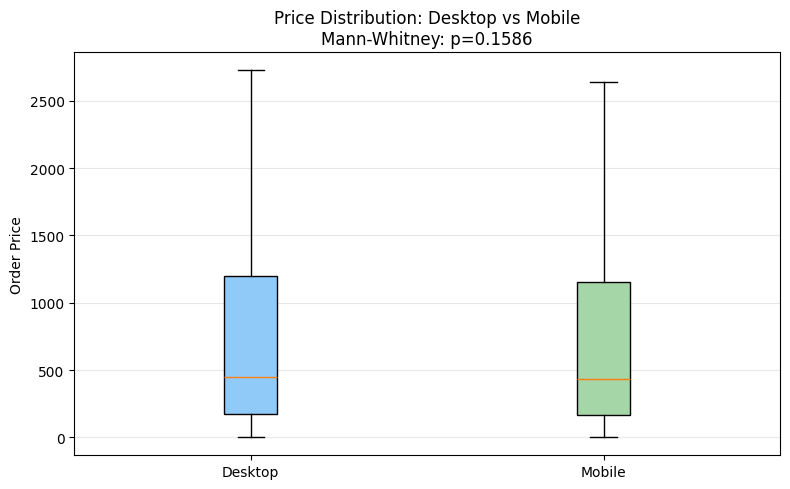

In [ ]:
# ─ Mann-Whitney: Average Order Value desktop vs mobile ───────────────────
# Question: does the AOV differ between desktop and mobile buyers?

desktop_prices = orders[orders['device'] == 'desktop']['price']
mobile_prices  = orders[orders['device'] == 'mobile']['price']

print(f"\nDesktop: n={len(desktop_prices):,}, median={desktop_prices.median():.1f}, "
      f"mean={desktop_prices.mean():.1f}")
print(f"Mobile:  n={len(mobile_prices):,}, median={mobile_prices.median():.1f}, "
      f"mean={mobile_prices.mean():.1f}")

stat, p_value = mannwhitneyu(desktop_prices, mobile_prices, alternative='two-sided')

print(f"\nMann-Whitney U Test:")
print(f"U Statistic: {stat:.0f}")
print(f"p-value: {p_value:.6f}")
print(f"Conclusion: {'Difference is significant ✓' if p_value < 0.05 else 'Difference is insignificant ✗'}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [desktop_prices, mobile_prices],
    labels=['Desktop', 'Mobile'],
    patch_artist=True,
    showfliers=False   # hide outliers to make the chart readable
)
bp['boxes'][0].set_facecolor('#90CAF9')
bp['boxes'][1].set_facecolor('#A5D6A7')
ax.set_title(f'Price Distribution: Desktop vs Mobile\nMann-Whitney: p={p_value:.4f}', fontsize=12)
ax.set_ylabel('Order Price')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test_desktop_vs_mobile.png', dpi=150, bbox_inches='tight')
plt.show()

The Mann-Whitney U test showed no statistically significant differences in the Average Order Value between Desktop and Mobile users (p > 0.05). This means that customers spend similar amounts of money regardless of whether they shop from a computer or a smartphone.

# **Tableau Dashboards**

In [ ]:
# ──  Saving data for Tableau ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/dashboard_data.csv', index=False)
print(f"Saved: {len(df):,} rows")

Mounted at /content/drive
Saved: 349,545 rows


https://public.tableau.com/app/profile/anna.savchuk6598/viz/E-commerceSalesOverview_17821451873840/E-commerceSalesOverview?publish=yes